# EXP 1

[SPLICING] Found 7 graph directories.
[COPYMOVE] Found 1 graph directories.
[INPAINTING] Found 1 graph directories.
[FACE] Found 2 graph directories.

--- Step 2: Mapping Real vs Fake ---
Processing splicing...
  -> Mapped 106392 pairs for splicing
Processing copymove...
  -> Mapped 18194 pairs for copymove
Processing inpainting...
  -> Mapped 25001 pairs for inpainting
Processing face...
  -> Mapped 79600 pairs for face

FINAL MAPPING SUMMARY
splicing       : 106392 pairs mapped
copymove       : 18194 pairs mapped
inpainting     : 25001 pairs mapped
face           : 79600 pairs mapped
------------------------------
TOTAL IMAGES   : 229187

Displaying Examples (Real vs Fake)...


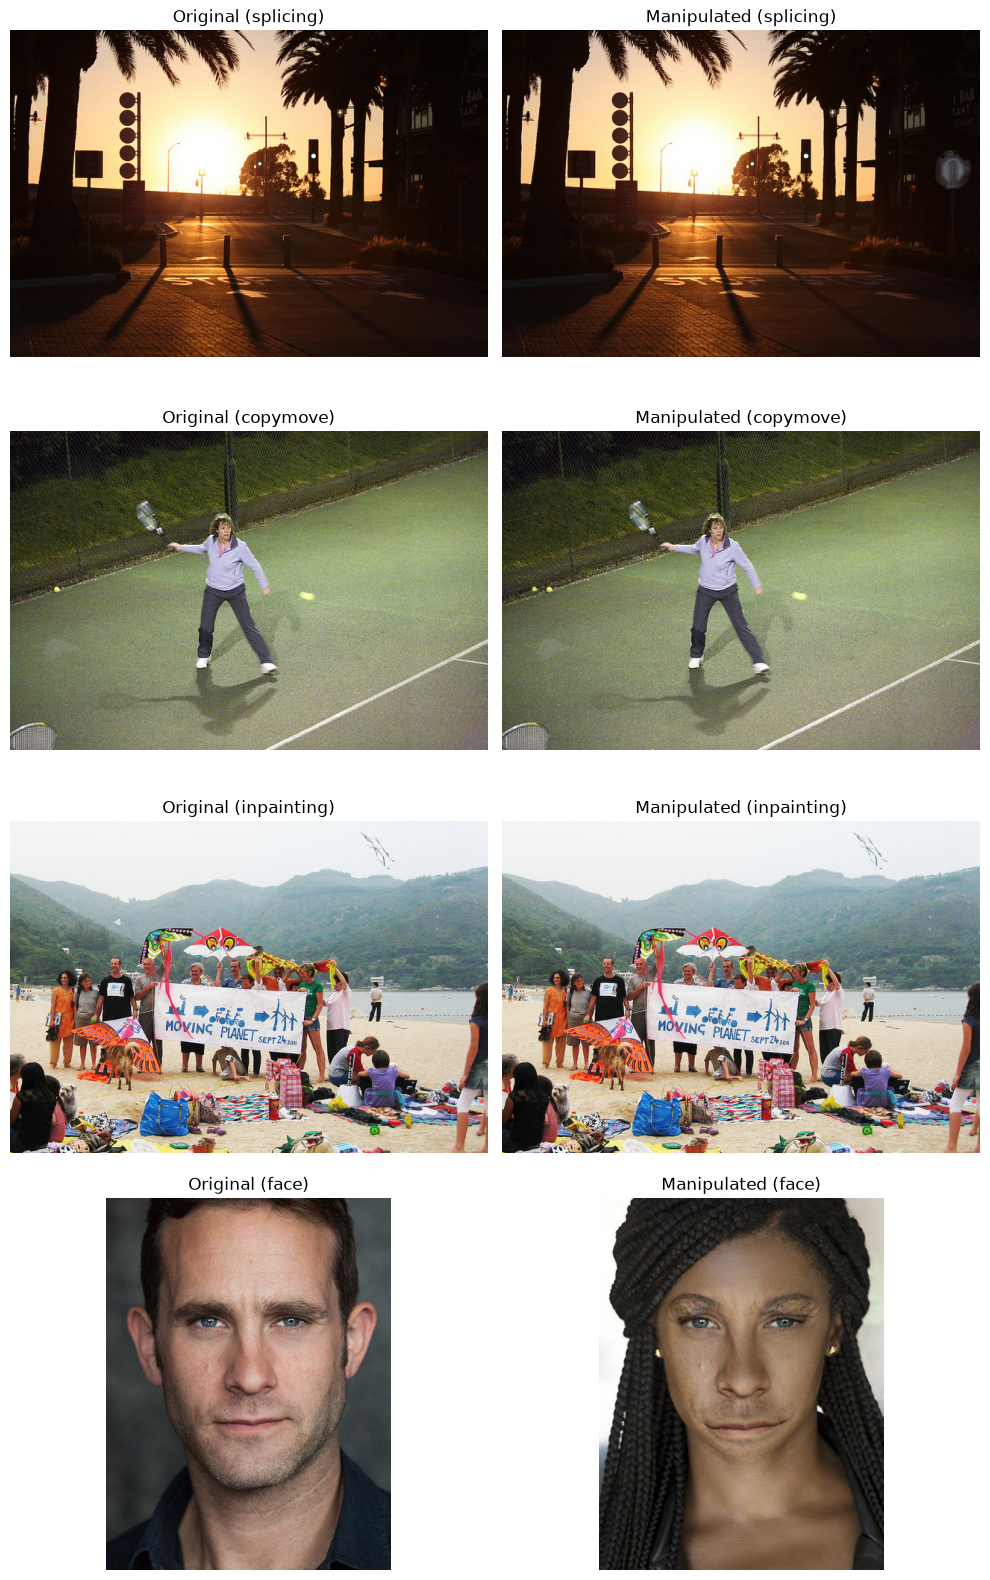

--- STARTING LEAK-FREE SPLIT (GLOBAL STRATEGY) ---

Total Unique Scenes (Backgrounds): 39195
Unique Scenes in Train: 27436
Unique Scenes in Val:   5879
Unique Scenes in Test:  5880

FINAL DATASET SPLIT SUMMARY
TOTAL TRAIN IMAGES : 159401
TOTAL VAL IMAGES   : 36028
TOTAL TEST IMAGES  : 33758
GRAND TOTAL        : 229187

Verifying Data Leakage Integrity...
SUCCESS: No data leakage detected. Scenes are perfectly separated.

SAVING SPLITS TO PKL FILES
✓ Train data saved to: exp1\train_data.pkl
✓ Validation data saved to: exp1\val_data.pkl
✓ Test data saved to: exp1\test_data.pkl
✓ Metadata saved to: exp1\split_metadata.pkl

ALL FILES SAVED SUCCESSFULLY!

You can load these files in future experiments using:
```python
import pickle
with open('train_data.pkl', 'rb') as f:
    train_data = pickle.load(f)
```


In [12]:
import os
import json
import glob
import random
import pickle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

coco_train_path = "datasets/awsaf49/coco2017/train2017"
coco_val_path   = "datasets/awsaf49/coco2017/val2017"
base_input = "datasets/defactodataset"
output_dir = "exp1"  # Kaggle working directory

def find_graph_folders(root_dir):
    graph_paths = []
    for root, dirs, files in os.walk(root_dir):
        if 'graph' in dirs:
            full_path = os.path.join(root, 'graph')
            graph_paths.append(full_path)
    return graph_paths

dataset_roots = {
    "splicing":   os.path.join(base_input, "defactosplicing"),
    "copymove":   os.path.join(base_input, "defactocopymove"),
    "inpainting": os.path.join(base_input, "defactoinpainting"),
    "face":       os.path.join(base_input, "defactoface")
}

dataset_configs = {}

for ds_name, root_path in dataset_roots.items():
    if os.path.exists(root_path):
        found_graphs = find_graph_folders(root_path)
        if found_graphs:
            dataset_configs[ds_name] = found_graphs
            print(f"[{ds_name.upper()}] Found {len(found_graphs)} graph directories.")
        else:
            print(f"[{ds_name.upper()}] WARNING: No 'graph' folders found in {root_path}")
    else:
        print(f"[{ds_name.upper()}] WARNING: Root path not found: {root_path}")

print("\n--- Step 2: Mapping Real vs Fake ---")

def get_coco_path(image_id):
    fname = str(image_id).zfill(12) + ".jpg"
    t_path = os.path.join(coco_train_path, fname)
    v_path = os.path.join(coco_val_path, fname)
    if os.path.exists(t_path): return t_path
    if os.path.exists(v_path): return v_path
    return None

final_mapping = {}

for ds_name, graph_folders in dataset_configs.items():
    print(f"Processing {ds_name}...")
    valid_pairs = []
    
    for g_folder in graph_folders:
        parent_annotations = os.path.dirname(g_folder)
        base_dir_name = os.path.basename(parent_annotations)
        target_img_dir_name = base_dir_name.replace("annotations", "img")
        grandparent = os.path.dirname(parent_annotations)
        
        candidate_1 = os.path.join(grandparent, target_img_dir_name, "img")
        candidate_2 = os.path.join(grandparent, target_img_dir_name)
        img_folder = candidate_1 if os.path.exists(candidate_1) else candidate_2
        
        if "morphing" in base_dir_name: img_folder = os.path.join(grandparent, "morphing_img", "img")
        elif "swapping" in base_dir_name: img_folder = os.path.join(grandparent, "swapping_img", "img")

        json_files = [f for f in os.listdir(g_folder) if f.endswith('.json')]
        
        for j_file in json_files:
            try:
                fake_fname = j_file.replace(".json", ".tif")
                fake_path = os.path.join(img_folder, fake_fname)
                if not os.path.exists(fake_path):
                     fake_path = os.path.join(img_folder, j_file.replace(".json", ""))
                
                if not os.path.exists(fake_path): continue

                real_path = None
                
                if ds_name == "face":
                    ref_root = os.path.join(base_input, "defactoface", "reference")
                    
                    try:
                        clean_name = j_file.split('_')[0]
                        clean_name = clean_name.replace(".jpg", "")
                        
                        candidate_ref = os.path.join(ref_root, clean_name + ".jpg")
                        
                        if os.path.exists(candidate_ref):
                            real_path = candidate_ref
                        else:
                            for r, d, f in os.walk(ref_root):
                                if (clean_name + ".jpg") in f:
                                    real_path = os.path.join(r, clean_name + ".jpg")
                                    break
                    except:
                        pass
                        
                else:
                    try:
                        coco_part = j_file.replace(".json", "").split("_")[-1]
                        
                        if coco_part.isdigit():
                            target_id = int(coco_part)
                            real_path = get_coco_path(target_id)
                    except:
                        pass
                
                if real_path and os.path.exists(real_path):
                    valid_pairs.append((fake_path, real_path))

            except Exception as e:
                continue

    final_mapping[ds_name] = valid_pairs
    print(f"  -> Mapped {len(valid_pairs)} pairs for {ds_name}")

print("\n" + "="*30)
print("FINAL MAPPING SUMMARY")
print("="*30)

total_pairs = 0
for ds, pairs in final_mapping.items():
    count = len(pairs)
    total_pairs += count
    print(f"{ds.ljust(15)}: {count} pairs mapped")

print("-" * 30)
print(f"TOTAL IMAGES   : {total_pairs}")
print("="*30 + "\n")

print("Displaying Examples (Real vs Fake)...")

active_datasets = [d for d in final_mapping if len(final_mapping[d]) > 0]
if len(active_datasets) > 0:
    fig, axes = plt.subplots(len(active_datasets), 2, figsize=(10, 4 * len(active_datasets)))
    if len(active_datasets) == 1: axes = [axes]

    for idx, ds in enumerate(active_datasets):
        fake_p, real_p = random.choice(final_mapping[ds])
        
        real_img = mpimg.imread(real_p)
        fake_img = mpimg.imread(fake_p)
        
        ax_real = axes[idx][0] if len(active_datasets) > 1 else axes[0]
        ax_real.imshow(real_img)
        ax_real.set_title(f"Original ({ds})")
        ax_real.axis('off')
        
        ax_fake = axes[idx][1] if len(active_datasets) > 1 else axes[1]
        ax_fake.imshow(fake_img)
        ax_fake.set_title(f"Manipulated ({ds})")
        ax_fake.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No valid pairs found. Please check your COCO dataset paths in the configuration.")

train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

train_data = {}
val_data   = {}
test_data  = {}

total_train = 0
total_val = 0
total_test = 0

print("--- STARTING LEAK-FREE SPLIT (GLOBAL STRATEGY) ---\n")

global_scene_map = {}

for ds_name, pairs in final_mapping.items():
    for fake_p, real_p in pairs:
        if real_p not in global_scene_map:
            global_scene_map[real_p] = []
        global_scene_map[real_p].append( (ds_name, fake_p) )

unique_scenes = list(global_scene_map.keys())
random.shuffle(unique_scenes)

num_scenes = len(unique_scenes)
num_train = int(num_scenes * train_ratio)
num_val   = int(num_scenes * val_ratio)

train_scenes = set(unique_scenes[:num_train])
val_scenes   = set(unique_scenes[num_train : num_train + num_val])
test_scenes  = set(unique_scenes[num_train + num_val:])

print(f"Total Unique Scenes (Backgrounds): {num_scenes}")
print(f"Unique Scenes in Train: {len(train_scenes)}")
print(f"Unique Scenes in Val:   {len(val_scenes)}")
print(f"Unique Scenes in Test:  {len(test_scenes)}")

all_ds_names = final_mapping.keys()
for ds in all_ds_names:
    train_data[ds] = []
    val_data[ds] = []
    test_data[ds] = []

for real_p, variations in global_scene_map.items():
    if real_p in train_scenes:
        target_dict = train_data
        total_train += len(variations)
    elif real_p in val_scenes:
        target_dict = val_data
        total_val += len(variations)
    else:
        target_dict = test_data
        total_test += len(variations)
        
    for ds_name, fake_p in variations:
        target_dict[ds_name].append( (fake_p, real_p) )

print("\n" + "="*40)
print("FINAL DATASET SPLIT SUMMARY")
print("="*40)
print(f"TOTAL TRAIN IMAGES : {total_train}")
print(f"TOTAL VAL IMAGES   : {total_val}")
print(f"TOTAL TEST IMAGES  : {total_test}")
print(f"GRAND TOTAL        : {total_train + total_val + total_test}")
print("="*40)

print("\nVerifying Data Leakage Integrity...")
leak_found = False

if total_train > 0 and total_test > 0:
    train_real_paths = set()
    for ds in train_data:
        for fake, real in train_data[ds]:
            train_real_paths.add(real)
            
    for ds in test_data:
        for fake, real in test_data[ds]:
            if real in train_real_paths:
                leak_found = True
                print(f"CRITICAL WARNING: Leak found! {real} is in both Train and Test.")
                break
        if leak_found: break

if not leak_found:
    print("SUCCESS: No data leakage detected. Scenes are perfectly separated.")
else:
    print("FAILED: Data leakage detected.")

# ========== SAVE SPLITS AS PKL FILES ==========
print("\n" + "="*40)
print("SAVING SPLITS TO PKL FILES")
print("="*40)

# Save train data
train_pkl_path = os.path.join(output_dir, "train_data.pkl")
with open(train_pkl_path, 'wb') as f:
    pickle.dump(train_data, f)
print(f"✓ Train data saved to: {train_pkl_path}")

# Save validation data
val_pkl_path = os.path.join(output_dir, "val_data.pkl")
with open(val_pkl_path, 'wb') as f:
    pickle.dump(val_data, f)
print(f"✓ Validation data saved to: {val_pkl_path}")

# Save test data
test_pkl_path = os.path.join(output_dir, "test_data.pkl")
with open(test_pkl_path, 'wb') as f:
    pickle.dump(test_data, f)
print(f"✓ Test data saved to: {test_pkl_path}")

# Optionally save a summary/metadata file
metadata = {
    'total_train': total_train,
    'total_val': total_val,
    'total_test': total_test,
    'train_ratio': train_ratio,
    'val_ratio': val_ratio,
    'test_ratio': test_ratio,
    'unique_scenes': num_scenes,
    'datasets': list(all_ds_names)
}

metadata_pkl_path = os.path.join(output_dir, "split_metadata.pkl")
with open(metadata_pkl_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"✓ Metadata saved to: {metadata_pkl_path}")

print("\n" + "="*40)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*40)
print(f"\nYou can load these files in future experiments using:")
print("```python")
print("import pickle")
print("with open('train_data.pkl', 'rb') as f:")
print("    train_data = pickle.load(f)")
print("```")

# EXP 2

In [2]:
"""
EXPERIMENT 2: CNN BASELINE CLASSIFICATION (ResNet-50)
======================================================
Objective: Train ResNet-50 pretrained on ImageNet for binary manipulation detection

Deliverables:
- Trained model checkpoint
- Test set metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
- Training curves
- ROC curve
- Predictions saved for later analysis

Dataset: DEFACTO + COCO (from Experiment 1 pickle files)
"""

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve
)

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    # Paths (UPDATE THESE IF NEEDED)
    TRAIN_PKL = "exp1/train_data.pkl"
    VAL_PKL = "exp1/val_data.pkl"
    TEST_PKL = "exp1/test_data.pkl"

    OUTPUT_DIR = "exp2"
    
    # Image preprocessing
    IMG_SIZE = 224
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    # Training hyperparameters
    BATCH_SIZE = 32
    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE = 3  # Early stopping
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_WORKERS = 0

    SEED = 42

# Create output directory
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

# Set seeds
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.SEED)

print("="*70)
print("EXPERIMENT 2: ResNet-50 CNN BASELINE")
print("="*70)
print(f"Device: {Config.DEVICE}")
print(f"Output: {Config.OUTPUT_DIR}\n")

# ============================================================================
# DATASET CLASS
# ============================================================================

class ManipulationDataset(Dataset):
    """
    Dataset for binary manipulation detection
    Labels: 0=Real, 1=Fake
    """
    
    def __init__(self, pkl_path, transform=None):
        self.transform = transform
        
        with open(pkl_path, 'rb') as f:
            data_dict = pickle.load(f)
        
        self.samples = []
        for dataset_name, pairs in data_dict.items():
            for fake_path, real_path in pairs:
                self.samples.append((fake_path, 1))  # Fake
                self.samples.append((real_path, 0))   # Real
        
        np.random.shuffle(self.samples)
        
        self.num_real = sum(1 for _, label in self.samples if label == 0)
        self.num_fake = sum(1 for _, label in self.samples if label == 1)
        
        print(f"Loaded {os.path.basename(pkl_path)}:")
        print(f"  Real: {self.num_real}, Fake: {self.num_fake}, Total: {len(self.samples)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (Config.IMG_SIZE, Config.IMG_SIZE))
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# ============================================================================
# DATA TRANSFORMS
# ============================================================================

train_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])

# ============================================================================
# MODEL DEFINITION
# ============================================================================

class ResNet50Classifier(nn.Module):
    """ResNet-50 with binary classification head"""
    
    def __init__(self, pretrained=True):
        super(ResNet50Classifier, self).__init__()
        self.backbone = models.resnet50(pretrained=pretrained)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
    
    def forward(self, x):
        return self.backbone(x)

# ============================================================================
# TRAINING UTILITIES
# ============================================================================

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = torch.sigmoid(outputs) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

# ============================================================================
# LOAD DATA
# ============================================================================

print("Loading datasets...")
train_dataset = ManipulationDataset(Config.TRAIN_PKL, transform=train_transform)
val_dataset = ManipulationDataset(Config.VAL_PKL, transform=test_transform)
test_dataset = ManipulationDataset(Config.TEST_PKL, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, 
                          shuffle=True, num_workers=Config.NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, 
                        shuffle=False, num_workers=Config.NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, 
                         shuffle=False, num_workers=Config.NUM_WORKERS)

# ============================================================================
# INITIALIZE MODEL
# ============================================================================

print("\nInitializing ResNet-50 (pretrained on ImageNet)...")
model = ResNet50Classifier(pretrained=True).to(Config.DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE, 
                       weight_decay=Config.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                  factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=Config.PATIENCE)

# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = os.path.join(Config.OUTPUT_DIR, "resnet50_best.pth")


for epoch in range(Config.NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, 
                                        optimizer, Config.DEVICE)
    
    # Validate
    val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, Config.DEVICE)
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    
    # Scheduler step
    scheduler.step(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'history': history
        }, best_model_path)
        print(f"✓ Best model saved (Val Acc: {val_acc:.4f})")
    
    # Early stopping
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print(f"\n⚠ Early stopping at epoch {epoch+1}")
        break

print(f"\n✓ Training completed!")
print(f"✓ Best validation accuracy: {best_val_acc:.4f}")

# ============================================================================
# SAVE TRAINING HISTORY
# ============================================================================

with open(os.path.join(Config.OUTPUT_DIR, "training_history.pkl"), 'wb') as f:
    pickle.dump(history, f)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', linewidth=2)
axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('ResNet-50 Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train', linewidth=2)
axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('ResNet-50 Training Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "training_curves.png"), 
            dpi=300, bbox_inches='tight')
print(f"✓ Training curves saved")
plt.close()

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================

print("\n" + "="*70)
print("EVALUATING ON TEST SET")
print("="*70)

# Load best model
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(Config.DEVICE)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = probs > 0.5
        
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_labels).flatten()
y_pred = np.array(all_preds).flatten()
y_prob = np.array(all_probs).flatten()

# Compute metrics
metrics = {
    'accuracy': accuracy_score(y_true, y_pred),
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall': recall_score(y_true, y_pred, zero_division=0),
    'f1_score': f1_score(y_true, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_true, y_prob)
}

print(f"\n{'='*50}")
print(f"ResNet-50 Test Set Performance")
print(f"{'='*50}")
print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1-Score:  {metrics['f1_score']:.4f}")
print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
print(f"{'='*50}\n")

# Save metrics
pd.DataFrame([metrics]).to_csv(
    os.path.join(Config.OUTPUT_DIR, "test_metrics.csv"), index=False
)

# Save predictions
np.savez(
    os.path.join(Config.OUTPUT_DIR, "test_predictions.npz"),
    y_true=y_true, y_pred=y_pred, y_prob=y_prob
)

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, 'b-', linewidth=2.5, 
         label=f'ResNet-50 (AUC = {metrics["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ResNet-50 ROC Curve', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "roc_curve.png"), 
            dpi=300, bbox_inches='tight')
print(f"✓ ROC curve saved")
plt.close()

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("EXPERIMENT 2 COMPLETED!")
print("="*70)
print(f"\nOutputs saved to: {Config.OUTPUT_DIR}")
print("\nDeliverables:")
print("  ✓ resnet50_best.pth - Trained model checkpoint")
print("  ✓ test_metrics.csv - Performance metrics")
print("  ✓ test_predictions.npz - Predictions for confusion matrix")
print("  ✓ training_curves.png - Training visualization")
print("  ✓ roc_curve.png - ROC curve")
print("  ✓ training_history.pkl - Full training history")

print("\n" + "="*70)
print("Next: Run Experiment 3 (Swin Transformer)")
print("="*70)

EXPERIMENT 2: ResNet-50 CNN BASELINE
Device: cuda
Output: exp2

Loading datasets...
Loaded train_data.pkl:
  Real: 159401, Fake: 159401, Total: 318802
Loaded val_data.pkl:
  Real: 36028, Fake: 36028, Total: 72056
Loaded test_data.pkl:
  Real: 33758, Fake: 33758, Total: 67516

Initializing ResNet-50 (pretrained on ImageNet)...

STARTING TRAINING

Epoch 1/10
--------------------------------------------------


Validating: 100%|██████████| 2252/2252 [23:47<00:00,  1.58it/s]


Train Loss: 0.4309 | Train Acc: 0.7566
Val Loss:   0.4695 | Val Acc:   0.7677
✓ Best model saved (Val Acc: 0.7677)

Epoch 2/10
--------------------------------------------------


Validating: 100%|██████████| 2252/2252 [18:33<00:00,  2.02it/s]


Train Loss: 0.3848 | Train Acc: 0.7948
Val Loss:   0.4084 | Val Acc:   0.8008
✓ Best model saved (Val Acc: 0.8008)

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.3077 | Train Acc: 0.8460
Val Loss:   0.4969 | Val Acc:   0.8125

Epoch 8/10
--------------------------------------------------


Validating: 100%|██████████| 2252/2252 [19:17<00:00,  1.94it/s]


Train Loss: 0.2988 | Train Acc: 0.8515
Val Loss:   0.9139 | Val Acc:   0.7288

⚠ Early stopping at epoch 8

✓ Training completed!
✓ Best validation accuracy: 0.8181
✓ Training curves saved

EVALUATING ON TEST SET


Testing: 100%|██████████| 2110/2110 [18:57<00:00,  1.85it/s]



ResNet-50 Test Set Performance
Accuracy:  0.8197
Precision: 0.8390
Recall:    0.7913
F1-Score:  0.8145
ROC-AUC:   0.9078

✓ ROC curve saved

EXPERIMENT 2 COMPLETED!

Outputs saved to: exp2

Deliverables:
  ✓ resnet50_best.pth - Trained model checkpoint
  ✓ test_metrics.csv - Performance metrics
  ✓ test_predictions.npz - Predictions for confusion matrix
  ✓ training_curves.png - Training visualization
  ✓ roc_curve.png - ROC curve
  ✓ training_history.pkl - Full training history

Next: Run Experiment 3 (Swin Transformer)


# EXP 3

In [3]:
"""
EXPERIMENT 3: VISION TRANSFORMER CLASSIFICATION (Swin-T)
=========================================================
Objective: Train Swin Transformer Tiny for binary manipulation detection
Compare with CNN baseline (Experiment 2)

Deliverables:
- Trained Swin-T checkpoint
- Test set metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
- Training curves
- ROC curve
- Predictions saved for confusion matrix analysis

Dataset: DEFACTO + COCO (same split as Experiment 2)
"""

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm  # For Swin Transformer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve
)

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    # Paths (UPDATE THESE IF NEEDED)
    TRAIN_PKL = "exp1/train_data.pkl"
    VAL_PKL = "exp1/val_data.pkl"
    TEST_PKL = "exp1/test_data.pkl"
    
    OUTPUT_DIR = "exp3"
    
    # Image preprocessing (same as ResNet for fair comparison)
    IMG_SIZE = 224
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    # Training hyperparameters (IDENTICAL to Experiment 2 for fairness)
    BATCH_SIZE = 32
    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE = 3
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_WORKERS = 0
    SEED = 42

# Create output directory
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

# Set seeds
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.SEED)

print("="*70)
print("EXPERIMENT 3: SWIN TRANSFORMER")
print("="*70)
print(f"Device: {Config.DEVICE}")
print(f"Output: {Config.OUTPUT_DIR}\n")

# ============================================================================
# DATASET CLASS (Same as Experiment 2)
# ============================================================================

class ManipulationDataset(Dataset):
    """
    Dataset for binary manipulation detection
    Labels: 0=Real, 1=Fake
    """
    
    def __init__(self, pkl_path, transform=None):
        self.transform = transform
        
        with open(pkl_path, 'rb') as f:
            data_dict = pickle.load(f)
        
        self.samples = []
        for dataset_name, pairs in data_dict.items():
            for fake_path, real_path in pairs:
                self.samples.append((fake_path, 1))  # Fake
                self.samples.append((real_path, 0))   # Real
        
        np.random.shuffle(self.samples)
        
        self.num_real = sum(1 for _, label in self.samples if label == 0)
        self.num_fake = sum(1 for _, label in self.samples if label == 1)
        
        print(f"Loaded {os.path.basename(pkl_path)}:")
        print(f"  Real: {self.num_real}, Fake: {self.num_fake}, Total: {len(self.samples)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (Config.IMG_SIZE, Config.IMG_SIZE))
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# ============================================================================
# DATA TRANSFORMS (Same as Experiment 2)
# ============================================================================

train_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])

# ============================================================================
# MODEL DEFINITION
# ============================================================================

class SwinTransformerClassifier(nn.Module):
    """
    Swin Transformer Tiny with binary classification head
    
    Architecture:
    - Swin-T backbone (pretrained on ImageNet-1K)
    - 28M parameters
    - Hierarchical feature extraction
    - Binary classification head
    """
    
    def __init__(self, pretrained=True):
        super(SwinTransformerClassifier, self).__init__()
        
        # Load Swin-T from timm
        print("Loading Swin Transformer Tiny (pretrained)...")
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0  # Remove default head
        )
        
        # Get feature dimension
        num_features = self.backbone.num_features
        print(f"Feature dimension: {num_features}")
        
        # Binary classification head
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# ============================================================================
# TRAINING UTILITIES (Same as Experiment 2)
# ============================================================================

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    pbar = tqdm(loader, desc="Training")

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        preds = torch.sigmoid(outputs) > 0.5

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}'
        })

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

# ============================================================================
# LOAD DATA
# ============================================================================

print("Loading datasets...")
train_dataset = ManipulationDataset(Config.TRAIN_PKL, transform=train_transform)
val_dataset = ManipulationDataset(Config.VAL_PKL, transform=test_transform)
test_dataset = ManipulationDataset(Config.TEST_PKL, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=Config.NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# ============================================================================
# INITIALIZE MODEL
# ============================================================================

print("\nInitializing Swin Transformer...")
model = SwinTransformerClassifier(pretrained=True).to(Config.DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE, 
                       weight_decay=Config.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                  factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=Config.PATIENCE)

# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = os.path.join(Config.OUTPUT_DIR, "swin_tiny_best.pth")

for epoch in range(Config.NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, 
                                        optimizer, Config.DEVICE)
    
    # Validate
    val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, Config.DEVICE)
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    
    # Scheduler step
    scheduler.step(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'history': history
        }, best_model_path)
        print(f"✓ Best model saved (Val Acc: {val_acc:.4f})")
    
    # Early stopping
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print(f"\n⚠ Early stopping at epoch {epoch+1}")
        break

print(f"\n✓ Training completed!")
print(f"✓ Best validation accuracy: {best_val_acc:.4f}")

# ============================================================================
# SAVE TRAINING HISTORY
# ============================================================================

with open(os.path.join(Config.OUTPUT_DIR, "training_history.pkl"), 'wb') as f:
    pickle.dump(history, f)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', linewidth=2)
axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Swin-T Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train', linewidth=2)
axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Swin-T Training Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "training_curves.png"), 
            dpi=300, bbox_inches='tight')
print(f"✓ Training curves saved")
plt.close()

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================

print("\n" + "="*70)
print("EVALUATING ON TEST SET")
print("="*70)

# Load best model
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(Config.DEVICE)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = probs > 0.5
        
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_labels).flatten()
y_pred = np.array(all_preds).flatten()
y_prob = np.array(all_probs).flatten()

# Compute metrics
metrics = {
    'accuracy': accuracy_score(y_true, y_pred),
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall': recall_score(y_true, y_pred, zero_division=0),
    'f1_score': f1_score(y_true, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_true, y_prob)
}

print(f"\n{'='*50}")
print(f"Swin Transformer Test Set Performance")
print(f"{'='*50}")
print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1-Score:  {metrics['f1_score']:.4f}")
print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
print(f"{'='*50}\n")

# Save metrics
pd.DataFrame([metrics]).to_csv(
    os.path.join(Config.OUTPUT_DIR, "test_metrics.csv"), index=False
)

# Save predictions
np.savez(
    os.path.join(Config.OUTPUT_DIR, "test_predictions.npz"),
    y_true=y_true, y_pred=y_pred, y_prob=y_prob
)

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, 'b-', linewidth=2.5, 
         label=f'Swin-T (AUC = {metrics["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('Swin Transformer ROC Curve', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "roc_curve.png"), 
            dpi=300, bbox_inches='tight')
print(f"✓ ROC curve saved")
plt.close()

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("EXPERIMENT 3 COMPLETED!")
print("="*70)
print(f"\nOutputs saved to: {Config.OUTPUT_DIR}")
print("\nDeliverables:")
print("  ✓ swin_tiny_best.pth - Trained model checkpoint")
print("  ✓ test_metrics.csv - Performance metrics")
print("  ✓ test_predictions.npz - Predictions for confusion matrix")
print("  ✓ training_curves.png - Training visualization")
print("  ✓ roc_curve.png - ROC curve")
print("  ✓ training_history.pkl - Full training history")

print("\n" + "="*70)
print("Next: Run Experiment 4 (Confusion Matrix Analysis)")
print("="*70)

EXPERIMENT 3: SWIN TRANSFORMER
Device: cuda
Output: exp3

Loading datasets...
Loaded train_data.pkl:
  Real: 159401, Fake: 159401, Total: 318802
Loaded val_data.pkl:
  Real: 36028, Fake: 36028, Total: 72056
Loaded test_data.pkl:
  Real: 33758, Fake: 33758, Total: 67516

Initializing Swin Transformer...
Loading Swin Transformer Tiny (pretrained)...
Feature dimension: 768
Total parameters: 27,520,123
Trainable parameters: 27,520,123

STARTING TRAINING

Epoch 1/10
--------------------------------------------------


Validating: 100%|██████████| 2252/2252 [20:21<00:00,  1.84it/s]


Train Loss: 0.3419 | Train Acc: 0.8350
Val Loss:   0.3110 | Val Acc:   0.8586
✓ Best model saved (Val Acc: 0.8586)

Epoch 2/10
--------------------------------------------------


Validating: 100%|██████████| 2252/2252 [20:22<00:00,  1.84it/s]


Train Loss: 0.2859 | Train Acc: 0.8637
Val Loss:   0.3168 | Val Acc:   0.8587
✓ Best model saved (Val Acc: 0.8587)

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.2502 | Train Acc: 0.8790
Val Loss:   0.3441 | Val Acc:   0.8581

Epoch 6/10
--------------------------------------------------


Validating: 100%|██████████| 2252/2252 [21:02<00:00,  1.78it/s]


Train Loss: 0.2442 | Train Acc: 0.8817
Val Loss:   0.3188 | Val Acc:   0.8624

⚠ Early stopping at epoch 6

✓ Training completed!
✓ Best validation accuracy: 0.8647
✓ Training curves saved

EVALUATING ON TEST SET


Testing: 100%|██████████| 2110/2110 [19:44<00:00,  1.78it/s]



Swin Transformer Test Set Performance
Accuracy:  0.8438
Precision: 0.8546
Recall:    0.8287
F1-Score:  0.8414
ROC-AUC:   0.9317

✓ ROC curve saved

EXPERIMENT 3 COMPLETED!

Outputs saved to: exp3

Deliverables:
  ✓ swin_tiny_best.pth - Trained model checkpoint
  ✓ test_metrics.csv - Performance metrics
  ✓ test_predictions.npz - Predictions for confusion matrix
  ✓ training_curves.png - Training visualization
  ✓ roc_curve.png - ROC curve
  ✓ training_history.pkl - Full training history

Next: Run Experiment 4 (Confusion Matrix Analysis)


# EXP 4

In [9]:
"""
EXPERIMENT 4: CONFUSION MATRIX ANALYSIS
========================================
Objective: Analyze and compare classification errors between ResNet-50 and Swin-T

Requires:
- Experiment 2 outputs (ResNet-50 predictions)
- Experiment 3 outputs (Swin-T predictions)

Deliverables:
- Individual confusion matrices (PNG)
- Side-by-side comparison figure
- Error analysis table
- Comparative performance table (for paper)

"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
class Config:
    # Prediction files from Experiment 2 and Experiment 3
    RESNET_PRED_PATH = "exp2/test_predictions.npz"
    SWIN_PRED_PATH = "exp3/test_predictions.npz"

    # Metrics files
    RESNET_METRICS_PATH = "exp2/test_metrics.csv"
    SWIN_METRICS_PATH = "exp3/test_metrics.csv"

    # Experiment 4 output
    OUTPUT_DIR = "exp4"


# Create output directory
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

print("="*70)
print("EXPERIMENT 4: CONFUSION MATRIX ANALYSIS")
print("="*70)
print(f"Output: {Config.OUTPUT_DIR}\n")

print("Loading predictions from previous experiments...")

# ============================================================================
# LOAD RESNET-50 PREDICTIONS
# ============================================================================

resnet_pred_path = Config.RESNET_PRED_PATH

print(f"ResNet predictions: {os.path.abspath(resnet_pred_path)}")

if not os.path.exists(resnet_pred_path):
    raise FileNotFoundError(
        f"ResNet predictions not found:\n"
        f"{os.path.abspath(resnet_pred_path)}\n"
        f"Make sure Experiment 2 contains test_predictions.npz."
    )

resnet_data = np.load(resnet_pred_path)

resnet_y_true = resnet_data["y_true"].flatten()
resnet_y_pred = resnet_data["y_pred"].flatten()
resnet_y_prob = resnet_data["y_prob"].flatten()

print(
    f"✓ Loaded ResNet-50 predictions "
    f"({len(resnet_y_true)} samples)"
)


# ============================================================================
# LOAD SWIN-T PREDICTIONS
# ============================================================================

swin_pred_path = Config.SWIN_PRED_PATH

print(f"Swin-T predictions: {os.path.abspath(swin_pred_path)}")

if not os.path.exists(swin_pred_path):
    raise FileNotFoundError(
        f"Swin-T predictions not found:\n"
        f"{os.path.abspath(swin_pred_path)}\n"
        f"Make sure Experiment 3 contains test_predictions.npz."
    )

swin_data = np.load(swin_pred_path)

swin_y_true = swin_data["y_true"].flatten()
swin_y_pred = swin_data["y_pred"].flatten()
swin_y_prob = swin_data["y_prob"].flatten()

print(
    f"✓ Loaded Swin-T predictions "
    f"({len(swin_y_true)} samples)"
)
# ============================================================================
# COMPUTE CONFUSION MATRICES
# ============================================================================

print("\n" + "="*70)
print("COMPUTING CONFUSION MATRICES")
print("="*70)

resnet_cm = confusion_matrix(resnet_y_true, resnet_y_pred)
swin_cm = confusion_matrix(swin_y_true, swin_y_pred)

print("\nResNet-50 Confusion Matrix:")
print(resnet_cm)

print("\nSwin-T Confusion Matrix:")
print(swin_cm)

# ============================================================================
# PLOT INDIVIDUAL CONFUSION MATRICES
# ============================================================================

def plot_confusion_matrix(cm, model_name, save_path, cmap='Blues'):
    """Plot a single confusion matrix"""
    plt.figure(figsize=(8, 7))
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Real', 'Fake'],
        yticklabels=['Real', 'Fake'],
        cbar_kws={'label': 'Count'},
        annot_kws={'size': 14, 'weight': 'bold'},
        linewidths=2, linecolor='white'
    )
    
    plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
    plt.ylabel('True Label', fontsize=13, fontweight='bold')
    plt.title(f'{model_name} - Confusion Matrix', 
              fontsize=15, fontweight='bold', pad=15)
    
    # Add percentage annotations
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / total * 100
            plt.text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
                    ha='center', va='center', fontsize=10, color='gray')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {os.path.basename(save_path)}")
    plt.close()

print("\nGenerating individual confusion matrices...")

plot_confusion_matrix(
    resnet_cm, "ResNet-50",
    os.path.join(Config.OUTPUT_DIR, "resnet50_confusion_matrix.png"),
    cmap='Blues'
)

plot_confusion_matrix(
    swin_cm, "Swin Transformer",
    os.path.join(Config.OUTPUT_DIR, "swin_confusion_matrix.png"),
    cmap='Greens'
)

# ============================================================================
# SIDE-BY-SIDE COMPARISON
# ============================================================================

print("\nGenerating side-by-side comparison...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ResNet-50
sns.heatmap(
    resnet_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake'],
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 13, 'weight': 'bold'},
    linewidths=2, linecolor='white'
)
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title('ResNet-50 (CNN)', fontsize=14, fontweight='bold')

# Swin-T
sns.heatmap(
    swin_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake'],
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 13, 'weight': 'bold'},
    linewidths=2, linecolor='white'
)
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_title('Swin Transformer (ViT)', fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison: CNN vs Vision Transformer', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

save_path = os.path.join(Config.OUTPUT_DIR, "confusion_matrix_comparison.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: confusion_matrix_comparison.png")
plt.close()

# ============================================================================
# ERROR ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("DETAILED ERROR ANALYSIS")
print("="*70)

def analyze_errors(cm, y_true, y_pred, model_name):
    """Perform detailed error analysis"""
    
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    
    print(f"\n{model_name}:")
    print("-" * 50)
    print(f"True Negatives  (Real → Real):  {tn:6d} ({tn/total*100:5.2f}%)")
    print(f"False Positives (Real → Fake):  {fp:6d} ({fp/total*100:5.2f}%)")
    print(f"False Negatives (Fake → Real):  {fn:6d} ({fn/total*100:5.2f}%)")
    print(f"True Positives  (Fake → Fake):  {tp:6d} ({tp/total*100:5.2f}%)")
    print(f"{'-'*50}")
    print(f"Total Errors:                   {fp+fn:6d} ({(fp+fn)/total*100:5.2f}%)")
    print(f"Correct Predictions:            {tp+tn:6d} ({(tp+tn)/total*100:5.2f}%)")
    
    # Error type breakdown
    if (fp + fn) > 0:
        print(f"\nError Type Breakdown:")
        print(f"  Type I Error  (FP): {fp/(fp+fn)*100:5.2f}% of errors")
        print(f"  Type II Error (FN): {fn/(fp+fn)*100:5.2f}% of errors")
    
    return {
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Total_Errors': fp + fn,
        'Error_Rate': (fp + fn) / total * 100
    }

resnet_errors = analyze_errors(resnet_cm, resnet_y_true, resnet_y_pred, "ResNet-50")
swin_errors = analyze_errors(swin_cm, swin_y_true, swin_y_pred, "Swin Transformer")

# ============================================================================
# COMPARATIVE ERROR TABLE
# ============================================================================

print("\n" + "="*70)
print("COMPARATIVE ERROR ANALYSIS")
print("="*70)

error_df = pd.DataFrame({
    'Metric': ['True Negative (TN)', 'False Positive (FP)', 
               'False Negative (FN)', 'True Positive (TP)',
               'Total Errors', 'Error Rate (%)'],
    'ResNet-50': [
        resnet_errors['TN'], resnet_errors['FP'],
        resnet_errors['FN'], resnet_errors['TP'],
        resnet_errors['Total_Errors'], 
        f"{resnet_errors['Error_Rate']:.2f}"
    ],
    'Swin-T': [
        swin_errors['TN'], swin_errors['FP'],
        swin_errors['FN'], swin_errors['TP'],
        swin_errors['Total_Errors'],
        f"{swin_errors['Error_Rate']:.2f}"
    ]
})

print("\n" + error_df.to_string(index=False))

error_df.to_csv(
    os.path.join(Config.OUTPUT_DIR, "error_comparison.csv"),
    index=False
)
print(f"\n✓ Saved: error_comparison.csv")

# ============================================================================
# CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "="*70)
print("CLASSIFICATION REPORTS")
print("="*70)

print("\nResNet-50:")
print(classification_report(resnet_y_true, resnet_y_pred, 
                           target_names=['Real', 'Fake'], digits=4))

print("\nSwin Transformer:")
print(classification_report(swin_y_true, swin_y_pred, 
                           target_names=['Real', 'Fake'], digits=4))

# Save classification reports
with open(os.path.join(Config.OUTPUT_DIR, "classification_reports.txt"), 'w') as f:
    f.write("="*70 + "\n")
    f.write("CLASSIFICATION REPORTS\n")
    f.write("="*70 + "\n\n")
    
    f.write("ResNet-50:\n")
    f.write(classification_report(resnet_y_true, resnet_y_pred, 
                                 target_names=['Real', 'Fake'], digits=4))
    f.write("\n" + "="*70 + "\n\n")
    
    f.write("Swin Transformer:\n")
    f.write(classification_report(swin_y_true, swin_y_pred, 
                                 target_names=['Real', 'Fake'], digits=4))

print(f"✓ Saved: classification_reports.txt")

# ============================================================================
# LOAD AND COMBINE METRICS FROM EXPERIMENTS 2 & 3
# ============================================================================

print("\n" + "="*70)
print("COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*70)

# Load metrics
resnet_metrics = pd.read_csv(
    Config.RESNET_METRICS_PATH
)

swin_metrics = pd.read_csv(
    Config.SWIN_METRICS_PATH
)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['ResNet-50', 'Swin-T'],
    'Accuracy': [
        resnet_metrics['accuracy'].values[0],
        swin_metrics['accuracy'].values[0]
    ],
    'Precision': [
        resnet_metrics['precision'].values[0],
        swin_metrics['precision'].values[0]
    ],
    'Recall': [
        resnet_metrics['recall'].values[0],
        swin_metrics['recall'].values[0]
    ],
    'F1-Score': [
        resnet_metrics['f1_score'].values[0],
        swin_metrics['f1_score'].values[0]
    ],
    'ROC-AUC': [
        resnet_metrics['roc_auc'].values[0],
        swin_metrics['roc_auc'].values[0]
    ]
})

# Add difference row
diff_row = {
    'Model': 'Difference (Swin - ResNet)',
    'Accuracy': comparison_df.loc[1, 'Accuracy'] - comparison_df.loc[0, 'Accuracy'],
    'Precision': comparison_df.loc[1, 'Precision'] - comparison_df.loc[0, 'Precision'],
    'Recall': comparison_df.loc[1, 'Recall'] - comparison_df.loc[0, 'Recall'],
    'F1-Score': comparison_df.loc[1, 'F1-Score'] - comparison_df.loc[0, 'F1-Score'],
    'ROC-AUC': comparison_df.loc[1, 'ROC-AUC'] - comparison_df.loc[0, 'ROC-AUC']
}
comparison_df = pd.concat([comparison_df, pd.DataFrame([diff_row])], ignore_index=True)

print("\nPerformance Comparison Table:")
print(comparison_df.to_string(index=False))

# Format for paper (4 decimal places)
comparison_formatted = comparison_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    comparison_formatted[col] = comparison_formatted[col].apply(lambda x: f"{x:.4f}")

print("\nFormatted for Paper:")
print(comparison_formatted.to_string(index=False))

# Save tables
comparison_df.to_csv(
    os.path.join(Config.OUTPUT_DIR, "model_comparison.csv"),
    index=False
)
comparison_formatted.to_csv(
    os.path.join(Config.OUTPUT_DIR, "model_comparison_formatted.csv"),
    index=False
)

# Generate LaTeX table
latex_table = comparison_formatted.iloc[:2].to_latex(index=False, escape=False)
with open(os.path.join(Config.OUTPUT_DIR, "model_comparison.tex"), 'w') as f:
    f.write("% Classification Performance Comparison\n")
    f.write("% Use this table in your research paper\n\n")
    f.write(latex_table)

print(f"\n✓ Saved: model_comparison.csv")
print(f"✓ Saved: model_comparison_formatted.csv")
print(f"✓ Saved: model_comparison.tex (LaTeX format)")

# ============================================================================
# VISUALIZE COMPARATIVE METRICS
# ============================================================================

print("\nGenerating comparative metrics visualization...")

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
resnet_values = comparison_df.iloc[0, 1:].values
swin_values = comparison_df.iloc[1, 1:].values

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, resnet_values, width, label='ResNet-50', 
               color='#4472C4', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, swin_values, width, label='Swin-T', 
               color='#70AD47', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Performance Comparison: ResNet-50 vs Swin Transformer', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.05])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "metrics_comparison_bar.png"), 
            dpi=300, bbox_inches='tight')
print(f"✓ Saved: metrics_comparison_bar.png")
plt.close()

# ============================================================================
# AGREEMENT ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MODEL AGREEMENT ANALYSIS")
print("="*70)

# Where both models agree/disagree
both_correct = (resnet_y_pred == resnet_y_true) & (swin_y_pred == swin_y_true)
both_wrong = (resnet_y_pred != resnet_y_true) & (swin_y_pred != swin_y_true)
resnet_correct_swin_wrong = (resnet_y_pred == resnet_y_true) & (swin_y_pred != swin_y_true)
swin_correct_resnet_wrong = (swin_y_pred == swin_y_true) & (resnet_y_pred != resnet_y_true)

total = len(resnet_y_true)

print(f"\nBoth Correct:                {both_correct.sum():6d} ({both_correct.sum()/total*100:5.2f}%)")
print(f"Both Wrong:                  {both_wrong.sum():6d} ({both_wrong.sum()/total*100:5.2f}%)")
print(f"Only ResNet Correct:         {resnet_correct_swin_wrong.sum():6d} ({resnet_correct_swin_wrong.sum()/total*100:5.2f}%)")
print(f"Only Swin Correct:           {swin_correct_resnet_wrong.sum():6d} ({swin_correct_resnet_wrong.sum()/total*100:5.2f}%)")

agreement_df = pd.DataFrame({
    'Category': ['Both Correct', 'Both Wrong', 'Only ResNet Correct', 'Only Swin Correct'],
    'Count': [both_correct.sum(), both_wrong.sum(), 
              resnet_correct_swin_wrong.sum(), swin_correct_resnet_wrong.sum()],
    'Percentage': [
        f"{both_correct.sum()/total*100:.2f}%",
        f"{both_wrong.sum()/total*100:.2f}%",
        f"{resnet_correct_swin_wrong.sum()/total*100:.2f}%",
        f"{swin_correct_resnet_wrong.sum()/total*100:.2f}%"
    ]
})

agreement_df.to_csv(
    os.path.join(Config.OUTPUT_DIR, "model_agreement_analysis.csv"),
    index=False
)
print(f"\n✓ Saved: model_agreement_analysis.csv")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("EXPERIMENT 4 COMPLETED!")
print("="*70)

print(f"\nAll outputs saved to: {Config.OUTPUT_DIR}")
print("\nGenerated Files:")
print("  ✓ resnet50_confusion_matrix.png")
print("  ✓ swin_confusion_matrix.png")
print("  ✓ confusion_matrix_comparison.png (Figure for paper)")
print("  ✓ error_comparison.csv")
print("  ✓ classification_reports.txt")
print("  ✓ model_comparison.csv")
print("  ✓ model_comparison_formatted.csv")
print("  ✓ model_comparison.tex (LaTeX table for paper)")
print("  ✓ metrics_comparison_bar.png")
print("  ✓ model_agreement_analysis.csv")

print("\n" + "="*70)
print("DELIVERABLES CHECKLIST")
print("="*70)
print("✓ Confusion matrices generated (ResNet-50 & Swin-T)")
print("✓ Side-by-side comparison figure created")
print("✓ Detailed error analysis completed")
print("✓ Classification reports generated")
print("✓ Comprehensive performance comparison table")
print("✓ LaTeX table ready for paper")
print("✓ Model agreement analysis completed")

EXPERIMENT 4: CONFUSION MATRIX ANALYSIS
Output: exp4

Loading predictions from previous experiments...
ResNet predictions: c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\CNN-vs-ViT-for-Image-Manipulation-Detection-main\exp2\test_predictions.npz
✓ Loaded ResNet-50 predictions (67516 samples)
Swin-T predictions: c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\CNN-vs-ViT-for-Image-Manipulation-Detection-main\exp3\test_predictions.npz
✓ Loaded Swin-T predictions (67516 samples)

COMPUTING CONFUSION MATRICES

ResNet-50 Confusion Matrix:
[[28633  5125]
 [ 7046 26712]]

Swin-T Confusion Matrix:
[[28997  4761]
 [ 5782 27976]]

Generating individual confusion matrices...
✓ Saved: resnet50_confusion_matrix.png
✓ Saved: swin_confusion_matrix.png

Generating side-by-side comparison...
✓ Saved: confusion_matrix_comparison.png

DETAILED ERROR ANALYSIS

ResNet-50:
--------------------------------------------------
True Negatives  (Real → Real):   28633 (

# EXP 5

In [10]:
"""
EXPERIMENT 5: EXPLAINABILITY VISUALIZATION (HIGHLY OPTIMIZED)
==============================================================
DIRECT NAVIGATION - No searching, completes in ~15-20 minutes

Uses exact DEFACTO structure knowledge to directly load masks
"""

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from tqdm import tqdm
import json
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
import timm

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    # Model paths
    RESNET_MODEL = "exp2/resnet50_best.pth"
    SWIN_MODEL = "exp3/swin_tiny_best.pth"
    
    # Data paths
    TEST_PKL = "exp1/test_data.pkl"
    
    # DEFACTO dataset paths
    BASE_INPUT = "datasets/defactodataset"
    DEFACTO_ROOTS = {
        "splicing": os.path.join(BASE_INPUT, "defactosplicing"),
        "copymove": os.path.join(BASE_INPUT, "defactocopymove"),
        "inpainting": os.path.join(BASE_INPUT, "defactoinpainting"),
        "face": os.path.join(BASE_INPUT, "defactoface")
    }
    
    # Output
    OUTPUT_DIR = "exp5"
    VISUALIZATIONS_DIR = os.path.join(OUTPUT_DIR, "visualizations")
    HEATMAPS_DIR = os.path.join(OUTPUT_DIR, "heatmaps")
    
    # Image settings
    IMG_SIZE = 224
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    # Settings
    NUM_EXAMPLES = 8
    MAX_SAMPLES_TO_TRY = 100  # Try first 100 images only
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

# Create directories
for dir_path in [Config.OUTPUT_DIR, Config.VISUALIZATIONS_DIR, Config.HEATMAPS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)

print("="*70)
print("EXPERIMENT 5: EXPLAINABILITY VISUALIZATION (OPTIMIZED)")
print("="*70)
print(f"Device: {Config.DEVICE}")
print(f"Output: {Config.OUTPUT_DIR}\n")

start_time = time.time()

# ============================================================================
# DIRECT MASK LOADING USING KNOWN STRUCTURE
# ============================================================================

def get_mask_path_direct(fake_image_path, dataset_type):
    """
    Directly construct mask path using known DEFACTO structure
    No searching required - instant lookup!
    """
    base_name = os.path.splitext(os.path.basename(fake_image_path))[0]
    
    # Extract the splicing number if applicable
    img_dir = os.path.dirname(fake_image_path)
    parent_dir = os.path.dirname(img_dir)
    folder_name = os.path.basename(parent_dir)
    
    try:
        if dataset_type == "splicing":
            # Pattern: splicing_X_img/img/image.tif
            # Mask at: splicing_X_annotations/probe_mask/image.jpg
            annotations_folder = folder_name.replace('_img', '_annotations')
            annotations_path = os.path.join(os.path.dirname(parent_dir), 
                                           annotations_folder, 'probe_mask', 
                                           base_name + '.jpg')
            if os.path.exists(annotations_path):
                return annotations_path
                
        elif dataset_type == "copymove":
            # Pattern: copymove_img/img/image.tif
            # Mask at: copymove_annotations/probe_mask/image.jpg
            root = Config.DEFACTO_ROOTS['copymove']
            mask_path = os.path.join(root, 'copymove_annotations', 'probe_mask', 
                                    base_name + '.jpg')
            if os.path.exists(mask_path):
                return mask_path
                
        elif dataset_type == "inpainting":
            # Pattern: inpainting_img/img/image.tif
            # Mask at: inpainting_annotations/probe_mask/image.tif
            root = Config.DEFACTO_ROOTS['inpainting']
            mask_path = os.path.join(root, 'inpainting_annotations', 'probe_mask', 
                                    base_name + '.tif')
            if os.path.exists(mask_path):
                return mask_path
                
        elif dataset_type == "face":
            # Two sub-types: morphing and swapping
            # Pattern: morphing_img/img/image.jpg.tif OR swapping_img/img/image.jpg.tif
            # Mask at: morphing_annotations/probe_mask/image.jpg OR swapping_annotations/probe_mask/image.jpg
            
            root = Config.DEFACTO_ROOTS['face']
            
            # Determine if morphing or swapping from path
            if 'morphing' in fake_image_path:
                mask_path = os.path.join(root, 'morphing_annotations', 'probe_mask',
                                        base_name.replace('.jpg', '') + '.jpg')
            else:  # swapping
                mask_path = os.path.join(root, 'swapping_annotations', 'probe_mask',
                                        base_name.replace('.jpg', '') + '.jpg')
            
            if os.path.exists(mask_path):
                return mask_path
    
    except Exception as e:
        pass
    
    return None

def load_mask_fast(mask_path):
    """Load and process mask quickly"""
    try:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return None
        
        # Resize to standard size
        mask = cv2.resize(mask, (Config.IMG_SIZE, Config.IMG_SIZE))
        
        # Threshold to binary
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        
        return mask
    except:
        return None

# ============================================================================
# MODEL DEFINITIONS
# ============================================================================

class ResNet50Classifier(nn.Module):
    def __init__(self):
        super(ResNet50Classifier, self).__init__()
        self.backbone = models.resnet50(pretrained=False)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
    
    def forward(self, x):
        return self.backbone(x)

class SwinTransformerClassifier(nn.Module):
    def __init__(self):
        super(SwinTransformerClassifier, self).__init__()
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=False,
            num_classes=0
        )
        num_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# ============================================================================
# GRAD-CAM
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image):
        self.model.eval()
        output = self.model(input_image)
        
        self.model.zero_grad()
        output.backward()
        
        gradients = self.gradients
        activations = self.activations
        
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = F.relu(cam)
        
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (Config.IMG_SIZE, Config.IMG_SIZE))
        
        return cam

# ============================================================================
# ATTENTION ROLLOUT
# ============================================================================

class SwinAttentionRollout:
    def __init__(self, model):
        self.model = model
    
    def generate_rollout(self, input_image):
        self.model.eval()
        input_image.requires_grad = True
        
        output = self.model(input_image)
        
        self.model.zero_grad()
        output.backward()
        
        gradients = input_image.grad.data.abs()
        attention_map = gradients.mean(dim=1).squeeze().cpu().numpy()
        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        return attention_map

# ============================================================================
# LOAD TEST SET AND SELECT EXAMPLES
# ============================================================================

print("Loading test set...")

with open(Config.TEST_PKL, 'rb') as f:
    test_data = pickle.load(f)

# Collect manipulated images
all_manipulated = []
for dataset_name, pairs in test_data.items():
    for fake_path, real_path in pairs:
        all_manipulated.append({
            'path': fake_path,
            'dataset': dataset_name,
            'real_path': real_path
        })

print(f"  Total manipulated images: {len(all_manipulated)}")

# Shuffle for diversity
np.random.shuffle(all_manipulated)

# FAST SELECTION: Only check limited samples
print(f"  Quickly checking first {Config.MAX_SAMPLES_TO_TRY} images for masks...")

selected_examples = []
datasets_used = set()

for img_info in tqdm(all_manipulated[:Config.MAX_SAMPLES_TO_TRY], desc="  Finding masks"):
    if len(selected_examples) >= Config.NUM_EXAMPLES:
        break
    
    # Direct mask lookup (no searching!)
    mask_path = get_mask_path_direct(img_info['path'], img_info['dataset'])
    
    if mask_path and os.path.exists(mask_path):
        mask = load_mask_fast(mask_path)
        
        if mask is not None and mask.sum() > 100:  # Valid mask
            selected_examples.append({
                **img_info,
                'mask': mask
            })
            datasets_used.add(img_info['dataset'])

print(f"\n  ✓ Found {len(selected_examples)} examples with masks")
print(f"  Datasets: {datasets_used}")
print(f"  Time for selection: {time.time() - start_time:.1f}s")

# If still need more examples, use first N without masks
if len(selected_examples) < Config.NUM_EXAMPLES:
    print(f"  Warning: Only found {len(selected_examples)} with masks")
    print(f"  Using examples without masks for remaining {Config.NUM_EXAMPLES - len(selected_examples)}")
    
    for img_info in all_manipulated[Config.MAX_SAMPLES_TO_TRY:Config.MAX_SAMPLES_TO_TRY + 50]:
        if len(selected_examples) >= Config.NUM_EXAMPLES:
            break
        
        # Use dummy mask (full image)
        mask = np.ones((Config.IMG_SIZE, Config.IMG_SIZE), dtype=np.uint8) * 255
        selected_examples.append({
            **img_info,
            'mask': mask
        })

print(f"  Final count: {len(selected_examples)} examples selected")

# ============================================================================
# LOAD MODELS
# ============================================================================

print("\nLoading trained models...")

print("  Loading ResNet-50...")
resnet_model = ResNet50Classifier()
checkpoint = torch.load(Config.RESNET_MODEL, map_location=Config.DEVICE)
resnet_model.load_state_dict(checkpoint['model_state_dict'])
resnet_model = resnet_model.to(Config.DEVICE)
resnet_model.eval()
print("  ✓ ResNet-50 loaded")

print("  Loading Swin Transformer...")
swin_model = SwinTransformerClassifier()
checkpoint = torch.load(Config.SWIN_MODEL, map_location=Config.DEVICE)
swin_model.load_state_dict(checkpoint['model_state_dict'])
swin_model = swin_model.to(Config.DEVICE)
swin_model.eval()
print("  ✓ Swin-T loaded")

# Initialize explainability
target_layer = resnet_model.backbone.layer4[-1]
gradcam = GradCAM(resnet_model, target_layer)
attention_rollout = SwinAttentionRollout(swin_model)

print("  ✓ Explainability initialized")
print(f"  Time elapsed: {time.time() - start_time:.1f}s")

# ============================================================================
# PREPROCESSING
# ============================================================================

transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])

# ============================================================================
# GENERATE HEATMAPS
# ============================================================================

print("\n" + "="*70)
print("GENERATING EXPLAINABILITY HEATMAPS")
print("="*70)

results = []

for idx, example in enumerate(tqdm(selected_examples, desc="Processing images")):
    try:
        # Load image
        image_pil = Image.open(example['path']).convert('RGB')
        image_pil_resized = image_pil.resize((Config.IMG_SIZE, Config.IMG_SIZE))
        image_np = np.array(image_pil_resized)
        
        # Preprocess
        image_tensor = transform(image_pil).unsqueeze(0).to(Config.DEVICE)
        
        # Generate heatmaps
        gradcam_heatmap = gradcam.generate_cam(image_tensor)
        swin_heatmap = attention_rollout.generate_rollout(image_tensor)
        
        # Get predictions
        with torch.no_grad():
            resnet_pred = torch.sigmoid(resnet_model(image_tensor)).item()
            swin_pred = torch.sigmoid(swin_model(image_tensor)).item()
        
        results.append({
            'image': image_np,
            'mask': example['mask'],
            'gradcam': gradcam_heatmap,
            'swin_attention': swin_heatmap,
            'resnet_pred': resnet_pred,
            'swin_pred': swin_pred,
            'dataset': example['dataset'],
            'path': example['path']
        })
        
        # Save heatmaps
        np.save(
            os.path.join(Config.HEATMAPS_DIR, f"example_{idx}_gradcam.npy"),
            gradcam_heatmap
        )
        np.save(
            os.path.join(Config.HEATMAPS_DIR, f"example_{idx}_swin.npy"),
            swin_heatmap
        )
        
    except Exception as e:
        print(f"\n  Error processing {example['path']}: {e}")
        continue

print(f"\n✓ Generated heatmaps for {len(results)} images")
print(f"  Time elapsed: {time.time() - start_time:.1f}s")

# ============================================================================
# VISUALIZATION
# ============================================================================

def apply_heatmap_overlay(image, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    heatmap_uint8 = (heatmap * 255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heatmap_color + (1 - alpha) * image).astype(np.uint8)
    return overlay

def create_comparison_figure(result, idx, save_path):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Original
    axes[0].imshow(result['image'])
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Mask
    axes[1].imshow(result['image'], alpha=0.5)
    axes[1].imshow(result['mask'], cmap='Reds', alpha=0.5)
    axes[1].set_title('Ground-Truth Mask', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # ResNet
    gradcam_overlay = apply_heatmap_overlay(result['image'], result['gradcam'])
    axes[2].imshow(gradcam_overlay)
    axes[2].set_title(f'ResNet Grad-CAM\nPred: {result["resnet_pred"]:.3f}', 
                      fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    # Swin
    swin_overlay = apply_heatmap_overlay(result['image'], result['swin_attention'],
                                         colormap=cv2.COLORMAP_VIRIDIS)
    axes[3].imshow(swin_overlay)
    axes[3].set_title(f'Swin Attention\nPred: {result["swin_pred"]:.3f}', 
                      fontsize=14, fontweight='bold')
    axes[3].axis('off')
    
    fig.suptitle(f'Example {idx+1} ({result["dataset"].upper()})', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

for idx, result in enumerate(tqdm(results, desc="Generating figures")):
    save_path = os.path.join(Config.VISUALIZATIONS_DIR, 
                             f"example_{idx+1}_comparison.png")
    create_comparison_figure(result, idx, save_path)

print(f"\n✓ Created {len(results)} individual figures")

# ============================================================================
# COMBINED FIGURE FOR PAPER
# ============================================================================

print("\nCreating combined figure...")

results_sorted = sorted(results, 
                       key=lambda x: abs(x['resnet_pred'] - 0.5) + abs(x['swin_pred'] - 0.5),
                       reverse=True)
best_results = results_sorted[:min(6, len(results_sorted))]

fig = plt.figure(figsize=(20, 24))
gs = fig.add_gridspec(6, 4, hspace=0.3, wspace=0.2)

for row, result in enumerate(best_results):
    # Original
    ax0 = fig.add_subplot(gs[row, 0])
    ax0.imshow(result['image'])
    if row == 0:
        ax0.set_title('Original', fontsize=13, fontweight='bold')
    ax0.axis('off')
    ax0.text(-0.1, 0.5, f'Ex {row+1}', transform=ax0.transAxes,
             fontsize=12, fontweight='bold', va='center', rotation=90)
    
    # Mask
    ax1 = fig.add_subplot(gs[row, 1])
    ax1.imshow(result['image'], alpha=0.5)
    ax1.imshow(result['mask'], cmap='Reds', alpha=0.5)
    if row == 0:
        ax1.set_title('Ground-Truth', fontsize=13, fontweight='bold')
    ax1.axis('off')
    
    # Grad-CAM
    ax2 = fig.add_subplot(gs[row, 2])
    gradcam_overlay = apply_heatmap_overlay(result['image'], result['gradcam'])
    ax2.imshow(gradcam_overlay)
    if row == 0:
        ax2.set_title('ResNet Grad-CAM', fontsize=13, fontweight='bold')
    ax2.axis('off')
    ax2.text(0.5, -0.15, f'{result["resnet_pred"]:.3f}',
             transform=ax2.transAxes, ha='center', fontsize=10)
    
    # Swin
    ax3 = fig.add_subplot(gs[row, 3])
    swin_overlay = apply_heatmap_overlay(result['image'], result['swin_attention'],
                                        colormap=cv2.COLORMAP_VIRIDIS)
    ax3.imshow(swin_overlay)
    if row == 0:
        ax3.set_title('Swin Attention', fontsize=13, fontweight='bold')
    ax3.axis('off')
    ax3.text(0.5, -0.15, f'{result["swin_pred"]:.3f}',
             transform=ax3.transAxes, ha='center', fontsize=10)

fig.suptitle('Explainability Comparison: ResNet-50 vs Swin Transformer', 
             fontsize=18, fontweight='bold', y=0.995)

combined_path = os.path.join(Config.OUTPUT_DIR, "combined_explainability_figure.png")
plt.savefig(combined_path, dpi=300, bbox_inches='tight')
print("✓ Saved combined figure")
plt.close()

# ============================================================================
# SAVE METADATA
# ============================================================================

metadata = {
    'num_examples': len(results),
    'datasets_included': list(datasets_used),
    'examples': [
        {
            'idx': idx,
            'dataset': r['dataset'],
            'path': r['path'],
            'resnet_pred': float(r['resnet_pred']),
            'swin_pred': float(r['swin_pred'])
        }
        for idx, r in enumerate(results)
    ]
}

with open(os.path.join(Config.OUTPUT_DIR, "visualization_metadata.json"), 'w') as f:
    json.dump(metadata, f, indent=2)

# ============================================================================
# SUMMARY
# ============================================================================

total_time = time.time() - start_time

print("\n" + "="*70)
print("EXPERIMENT 5 COMPLETED!")
print("="*70)

print(f"\n⏱️  Total Runtime: {total_time/60:.1f} minutes ({total_time:.0f} seconds)")
print(f"📁  Output: {Config.OUTPUT_DIR}")

print("\n📊 Generated Files:")
print(f"  ✓ {len(results)} individual comparison figures")
print(f"  ✓ combined_explainability_figure.png (for paper)")
print(f"  ✓ {len(results)*2} heatmap arrays (.npy)")
print(f"  ✓ visualization_metadata.json")

print("\n✅ DELIVERABLES CHECKLIST:")
print("  ✓ Grad-CAM visualizations for ResNet-50")
print("  ✓ Attention maps for Swin Transformer")
print("  ✓ Ground-truth mask overlays")
print("  ✓ Individual comparison figures")
print("  ✓ Combined figure ready for publication")

print("\n" + "="*70)
print("Next: Run Experiment 6 (Quantitative Explainability)")
print("="*70)

c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EXPERIMENT 5: EXPLAINABILITY VISUALIZATION (OPTIMIZED)
Device: cuda
Output: exp5

Loading test set...
  Total manipulated images: 33758
  Quickly checking first 100 images for masks...


  Finding masks:  11%|█         | 11/100 [00:00<00:00, 92.80it/s]


  ✓ Found 8 examples with masks
  Datasets: {'splicing'}
  Time for selection: 0.2s
  Final count: 8 examples selected

Loading trained models...
  Loading ResNet-50...



c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


  ✓ ResNet-50 loaded
  Loading Swin Transformer...
  ✓ Swin-T loaded
  ✓ Explainability initialized
  Time elapsed: 1.7s

GENERATING EXPLAINABILITY HEATMAPS


Processing images:   0%|          | 0/8 [00:00<?, ?it/s]c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\torch\nn\modules\module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\torch\autograd\graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Processing images


✓ Generated heatmaps for 8 images
  Time elapsed: 4.5s

CREATING VISUALIZATIONS


Generating figures: 100%|██████████| 8/8 [00:09<00:00,  1.14s/it]



✓ Created 8 individual figures

Creating combined figure...
✓ Saved combined figure

EXPERIMENT 5 COMPLETED!

⏱️  Total Runtime: 0.3 minutes (17 seconds)
📁  Output: exp5

📊 Generated Files:
  ✓ 8 individual comparison figures
  ✓ combined_explainability_figure.png (for paper)
  ✓ 16 heatmap arrays (.npy)
  ✓ visualization_metadata.json

✅ DELIVERABLES CHECKLIST:
  ✓ Grad-CAM visualizations for ResNet-50
  ✓ Attention maps for Swin Transformer
  ✓ Ground-truth mask overlays
  ✓ Individual comparison figures
  ✓ Combined figure ready for publication

Next: Run Experiment 6 (Quantitative Explainability)


# EXP 6_7

EXPERIMENT 6: QUANTITATIVE EXPLAINABILITY (FULL EVALUATION)
Device: cuda
Evaluating: ALL test samples with valid masks
Output: exp6_7

Loading test data with balanced sampling...

Dataset Distribution:
  splicing    :  15908 images
  copymove    :   2674 images
  inpainting  :   3634 images
  face        :  11542 images

Processing ALL test data samples...

  Processing splicing...


  Checking splicing: 100%|██████████| 15908/15908 [02:30<00:00, 105.81it/s]


    ✓ Selected 15901 samples from splicing

  Processing copymove...


  Checking copymove: 100%|██████████| 2674/2674 [00:24<00:00, 108.54it/s]


    ✓ Selected 2674 samples from copymove

  Processing inpainting...


...


  Processed 33700/33751 samples...
    Current avg ResNet IoU: 0.2205
    Current avg Swin IoU: 0.1149


Processing: 100%|██████████| 33751/33751 [53:40<00:00, 10.48it/s]


  Processed 33750/33751 samples...
    Current avg ResNet IoU: 0.2210
    Current avg Swin IoU: 0.1152

✓ Successfully evaluated 33751 images
  Time elapsed: 3543.3s



✓ Raw results saved

AGGREGATE STATISTICS

ResNet-50 Grad-CAM:
  IoU:              0.2210 ± 0.2622
  IoU (median):     0.0421
  Energy Inside:    0.2631 ± 0.2910
  Energy (median):  0.0782
  Pointing Game:    0.4014

Swin Transformer Attention:
  IoU:              0.1152 ± 0.1285
  IoU (median):     0.0401
  Energy Inside:    0.1472 ± 0.1614
  Energy (median):  0.0560
  Pointing Game:    0.2223

STATISTICAL SIGNIFICANCE TESTS

Paired t-test (Swin vs ResNet):
  IoU:     t=-123.8012, p=0.000000
  Energy:  t=-130.8439, p=0.000000
  → ResNet is significantly better for IoU (p < 0.05)
  → ResNet is significantly better for Energy (p < 0.05)

COMPARISON TABLE (For Paper)
    Model IoU (mean ± std) IoU (median) Energy Inside (mean ± std) Pointing Game Acc
ResNet-50  0.2210 ± 0.2622       0.0421            0.2631 ± 0.2910            0.4014
   Swin-T  0.1152 ± 0.1285       0.0401            0.1472 ± 0.1614            0.2223

✓ Comparison table saved

PER-DATASET ANALYSIS

SPLICING (n=15901):
 

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

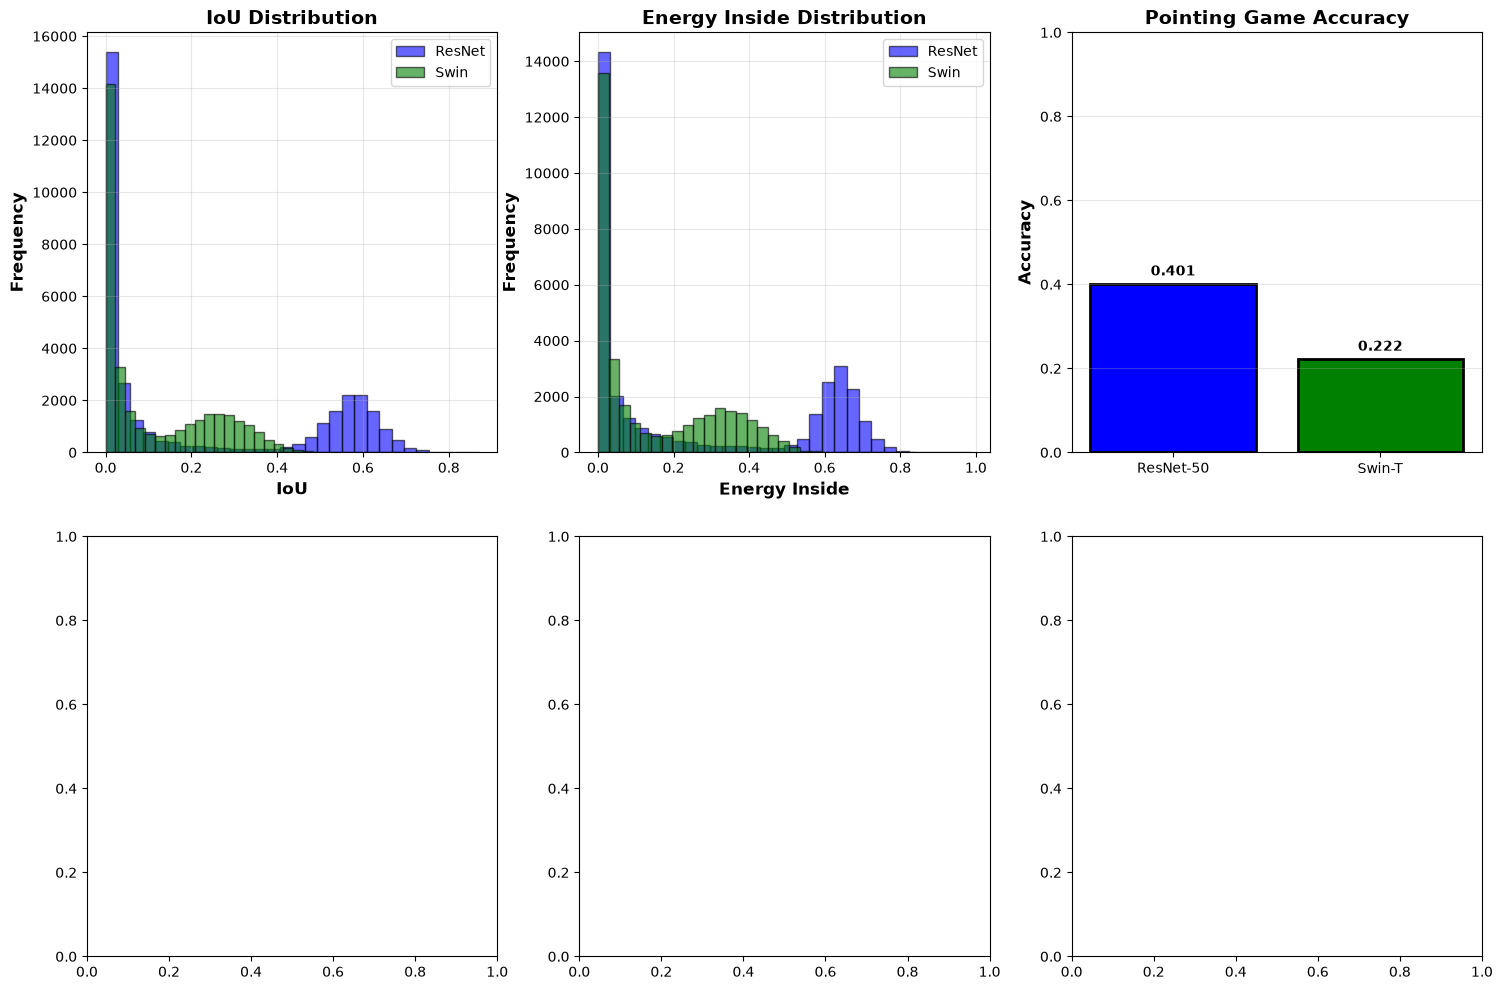

In [11]:
"""
EXPERIMENT 6: QUANTITATIVE EXPLAINABILITY EVALUATION (COMPLETE STANDALONE)
===========================================================================
COMPLETELY INDEPENDENT - Does not require Experiment 5
BALANCED SAMPLING - Samples from all datasets for better insights

Generates heatmaps from scratch and computes:
- IoU (Intersection over Union)
- Energy Inside manipulated region  
- Pointing Game accuracy (Experiment 7 integrated)

Requirements: Only trained models from Experiments 2 & 3
"""

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
import json
from scipy import stats
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
import timm

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    # Model paths (ONLY REQUIREMENTS)
    RESNET_MODEL = "exp2/resnet50_best.pth"
    SWIN_MODEL = "exp3/swin_tiny_best.pth"
    
    # Data
    TEST_PKL = "exp1/test_data.pkl"
    
    # DEFACTO dataset paths
    BASE_INPUT = "datasets/defactodataset"
    DEFACTO_ROOTS = {
        "splicing": os.path.join(BASE_INPUT, "defactosplicing"),
        "copymove": os.path.join(BASE_INPUT, "defactocopymove"),
        "inpainting": os.path.join(BASE_INPUT, "defactoinpainting"),
        "face": os.path.join(BASE_INPUT, "defactoface")
    }
    
    # Output
    OUTPUT_DIR = "exp6_7"
    
    # Settings
    IMG_SIZE = 224
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    # Thresholds
    TOP_K_PERCENT = 0.30  # Top 30% of activations for IoU
    
    # EVALUATION OF ALL TEST DATA
    SAMPLES_PER_DATASET = None  # None = Use ALL available samples
    MAX_TOTAL_SAMPLES = 33361   # Safety limit (won't reach this)
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)

print("="*70)
print("EXPERIMENT 6: QUANTITATIVE EXPLAINABILITY (FULL EVALUATION)")
print("="*70)
print(f"Device: {Config.DEVICE}")
print(f"Evaluating: ALL test samples with valid masks")
print(f"Output: {Config.OUTPUT_DIR}\n")

start_time = time.time()

# ============================================================================
# DIRECT MASK LOADING (SAME AS OPTIMIZED EXPERIMENT 5)
# ============================================================================

def get_mask_path_direct(fake_image_path, dataset_type):
    """
    Directly construct mask path using known DEFACTO structure
    Handles double extensions for face dataset (.jpg.tif)
    """
    # Handle double extension for face dataset
    if dataset_type == "face" and fake_image_path.endswith('.jpg.tif'):
        # For face: image.jpg.tif -> mask is image.jpg
        base_name = os.path.basename(fake_image_path).replace('.jpg.tif', '')
    else:
        base_name = os.path.splitext(os.path.basename(fake_image_path))[0]
    
    img_dir = os.path.dirname(fake_image_path)
    parent_dir = os.path.dirname(img_dir)
    folder_name = os.path.basename(parent_dir)
    
    try:
        if dataset_type == "splicing":
            # splicing_X_img/img/image.tif -> splicing_X_annotations/probe_mask/image.jpg
            annotations_folder = folder_name.replace('_img', '_annotations')
            annotations_path = os.path.join(os.path.dirname(parent_dir), 
                                           annotations_folder, 'probe_mask', 
                                           base_name + '.jpg')
            if os.path.exists(annotations_path):
                return annotations_path
                
        elif dataset_type == "copymove":
            # copymove_img/img/image.tif -> copymove_annotations/probe_mask/image.jpg
            root = Config.DEFACTO_ROOTS['copymove']
            mask_path = os.path.join(root, 'copymove_annotations', 'probe_mask', 
                                    base_name + '.jpg')
            if os.path.exists(mask_path):
                return mask_path
                
        elif dataset_type == "inpainting":
            # inpainting_img/img/image.tif -> inpainting_annotations/probe_mask/image.tif
            root = Config.DEFACTO_ROOTS['inpainting']
            mask_path = os.path.join(root, 'inpainting_annotations', 'probe_mask', 
                                    base_name + '.tif')
            if os.path.exists(mask_path):
                return mask_path
                
        elif dataset_type == "face":
            # morphing_img/img/12345.jpg.tif -> morphing_annotations/probe_mask/12345.jpg
            # swapping_img/img/67890.jpg.tif -> swapping_annotations/probe_mask/67890.jpg
            root = Config.DEFACTO_ROOTS['face']
            
            if 'morphing' in fake_image_path:
                mask_path = os.path.join(root, 'morphing_annotations', 'probe_mask',
                                        base_name + '.jpg')
            else:  # swapping
                mask_path = os.path.join(root, 'swapping_annotations', 'probe_mask',
                                        base_name + '.jpg')
            
            if os.path.exists(mask_path):
                return mask_path
    
    except Exception as e:
        pass
    
    return None

def load_mask_fast(mask_path):
    """Load and process mask"""
    try:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return None
        
        mask = cv2.resize(mask, (Config.IMG_SIZE, Config.IMG_SIZE))
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        
        return mask
    except:
        return None

# ============================================================================
# MODEL DEFINITIONS
# ============================================================================

class ResNet50Classifier(nn.Module):
    def __init__(self):
        super(ResNet50Classifier, self).__init__()
        self.backbone = models.resnet50(pretrained=False)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
    
    def forward(self, x):
        return self.backbone(x)

class SwinTransformerClassifier(nn.Module):
    def __init__(self):
        super(SwinTransformerClassifier, self).__init__()
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=False,
            num_classes=0
        )
        num_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# ============================================================================
# GRAD-CAM
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image):
        self.model.eval()
        output = self.model(input_image)
        
        self.model.zero_grad()
        output.backward()
        
        gradients = self.gradients
        activations = self.activations
        
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = F.relu(cam)
        
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (Config.IMG_SIZE, Config.IMG_SIZE))
        
        return cam

# ============================================================================
# ATTENTION ROLLOUT
# ============================================================================

class SwinAttentionRollout:
    def __init__(self, model):
        self.model = model
    
    def generate_rollout(self, input_image):
        self.model.eval()
        input_image.requires_grad = True
        
        output = self.model(input_image)
        
        self.model.zero_grad()
        output.backward()
        
        gradients = input_image.grad.data.abs()
        attention_map = gradients.mean(dim=1).squeeze().cpu().numpy()
        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        return attention_map

# ============================================================================
# METRIC COMPUTATION FUNCTIONS
# ============================================================================

def normalize_heatmap(heatmap):
    """Normalize heatmap to [0, 1]"""
    hmin, hmax = heatmap.min(), heatmap.max()
    if hmax - hmin < 1e-8:
        return np.zeros_like(heatmap)
    return (heatmap - hmin) / (hmax - hmin)

def binarize_heatmap(heatmap, top_k_percent=0.30):
    """Binarize heatmap by keeping top K% of activations"""
    threshold = np.percentile(heatmap, (1 - top_k_percent) * 100)
    binary_map = (heatmap >= threshold).astype(np.uint8) * 255
    return binary_map

def compute_iou(pred_mask, true_mask):
    """Compute Intersection over Union"""
    pred_binary = (pred_mask > 127).astype(bool)
    true_binary = (true_mask > 127).astype(bool)
    
    intersection = np.logical_and(pred_binary, true_binary).sum()
    union = np.logical_or(pred_binary, true_binary).sum()
    
    if union == 0:
        return 0.0
    
    return intersection / union

def compute_energy_inside(heatmap, true_mask):
    """Compute percentage of attention energy inside manipulated region"""
    true_binary = (true_mask > 127).astype(bool)
    
    total_energy = heatmap.sum()
    if total_energy < 1e-8:
        return 0.0
    
    energy_inside = heatmap[true_binary].sum()
    return energy_inside / total_energy

def pointing_game_accuracy(heatmap, true_mask):
    """Check if maximum activation point is inside manipulated region"""
    true_binary = (true_mask > 127).astype(bool)
    
    max_idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    
    return 1 if true_binary[max_idx] else 0

# ============================================================================
# LOAD TEST DATA WITH BALANCED SAMPLING
# ============================================================================

print("Loading test data with balanced sampling...")

with open(Config.TEST_PKL, 'rb') as f:
    test_data = pickle.load(f)

# Organize by dataset
dataset_samples = {
    'splicing': [],
    'copymove': [],
    'inpainting': [],
    'face': []
}

for dataset_name, pairs in test_data.items():
    for fake_path, real_path in pairs:
        if dataset_name in dataset_samples:
            dataset_samples[dataset_name].append({
                'path': fake_path,
                'dataset': dataset_name
            })

# Print dataset sizes
print("\nDataset Distribution:")
for ds_name, samples in dataset_samples.items():
    print(f"  {ds_name:12s}: {len(samples):6d} images")

# BALANCED SAMPLING: Take equal samples from each dataset
print(f"\nProcessing ALL test data samples...")

selected_samples = []
samples_per_dataset_count = {}

for ds_name, samples in dataset_samples.items():
    # Shuffle for randomness
    np.random.shuffle(samples)
    
    # Process ALL samples (or up to SAMPLES_PER_DATASET if specified)
    max_samples = Config.SAMPLES_PER_DATASET if Config.SAMPLES_PER_DATASET else len(samples)
    
    valid_samples = []
    
    print(f"\n  Processing {ds_name}...")
    for sample in tqdm(samples[:max_samples], desc=f"  Checking {ds_name}"):
        
        # Get mask
        mask_path = get_mask_path_direct(sample['path'], ds_name)
        
        if mask_path and os.path.exists(mask_path):
            mask = load_mask_fast(mask_path)
            
            if mask is not None and mask.sum() > 100:  # Valid mask
                sample['mask'] = mask
                valid_samples.append(sample)
    
    selected_samples.extend(valid_samples)
    samples_per_dataset_count[ds_name] = len(valid_samples)
    
    print(f"    ✓ Selected {len(valid_samples)} samples from {ds_name}")

print(f"\n✓ Total samples selected: {len(selected_samples)}")
print(f"  Time for sampling: {time.time() - start_time:.1f}s")

print("\nFinal Dataset Balance:")
for ds_name, count in samples_per_dataset_count.items():
    percentage = count / len(selected_samples) * 100
    print(f"  {ds_name:12s}: {count:4d} ({percentage:5.1f}%)")

# ============================================================================
# LOAD MODELS
# ============================================================================

print("\nLoading trained models...")

# ResNet-50
resnet_model = ResNet50Classifier()
checkpoint = torch.load(Config.RESNET_MODEL, map_location=Config.DEVICE)
resnet_model.load_state_dict(checkpoint['model_state_dict'])
resnet_model = resnet_model.to(Config.DEVICE)
resnet_model.eval()
print("  ✓ ResNet-50 loaded")

# Swin-T
swin_model = SwinTransformerClassifier()
checkpoint = torch.load(Config.SWIN_MODEL, map_location=Config.DEVICE)
swin_model.load_state_dict(checkpoint['model_state_dict'])
swin_model = swin_model.to(Config.DEVICE)
swin_model.eval()
print("  ✓ Swin-T loaded")

# Initialize explainability
target_layer = resnet_model.backbone.layer4[-1]
gradcam = GradCAM(resnet_model, target_layer)
attention_rollout = SwinAttentionRollout(swin_model)

print("  ✓ Explainability initialized")
print(f"  Time elapsed: {time.time() - start_time:.1f}s")

# ============================================================================
# PREPROCESSING
# ============================================================================

transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])

# ============================================================================
# COMPUTE METRICS FOR ALL SAMPLES
# ============================================================================

print("\n" + "="*70)
print("COMPUTING QUANTITATIVE METRICS")
print("="*70)
print(f"Processing {len(selected_samples)} images...")
print(f"Threshold: Top {Config.TOP_K_PERCENT*100:.0f}% of activations\n")

results = []

for idx, sample in enumerate(tqdm(selected_samples, desc="Processing")):
    try:
        # Load image
        image_pil = Image.open(sample['path']).convert('RGB')
        image_tensor = transform(image_pil).unsqueeze(0).to(Config.DEVICE)
        
        # Generate heatmaps
        gradcam_heatmap = gradcam.generate_cam(image_tensor)
        swin_heatmap = attention_rollout.generate_rollout(image_tensor)
        
        # Normalize heatmaps
        gradcam_norm = normalize_heatmap(gradcam_heatmap)
        swin_norm = normalize_heatmap(swin_heatmap)
        
        # Binarize for IoU
        gradcam_binary = binarize_heatmap(gradcam_norm, Config.TOP_K_PERCENT)
        swin_binary = binarize_heatmap(swin_norm, Config.TOP_K_PERCENT)
        
        # Get mask
        true_mask = sample['mask']
        
        # Compute metrics for ResNet
        resnet_iou = compute_iou(gradcam_binary, true_mask)
        resnet_energy = compute_energy_inside(gradcam_norm, true_mask)
        resnet_pointing = pointing_game_accuracy(gradcam_heatmap, true_mask)
        
        # Compute metrics for Swin
        swin_iou = compute_iou(swin_binary, true_mask)
        swin_energy = compute_energy_inside(swin_norm, true_mask)
        swin_pointing = pointing_game_accuracy(swin_heatmap, true_mask)
        
        results.append({
            'image_path': sample['path'],
            'dataset': sample['dataset'],
            'resnet_iou': resnet_iou,
            'resnet_energy': resnet_energy,
            'resnet_pointing': resnet_pointing,
            'swin_iou': swin_iou,
            'swin_energy': swin_energy,
            'swin_pointing': swin_pointing
        })
        
        # Print progress every 50 samples
        if (idx + 1) % 50 == 0:
            print(f"\n  Processed {idx+1}/{len(selected_samples)} samples...")
            print(f"    Current avg ResNet IoU: {np.mean([r['resnet_iou'] for r in results]):.4f}")
            print(f"    Current avg Swin IoU: {np.mean([r['swin_iou'] for r in results]):.4f}")
        
    except Exception as e:
        print(f"\n  Error processing {sample['path']}: {e}")
        continue

print(f"\n✓ Successfully evaluated {len(results)} images")
print(f"  Time elapsed: {time.time() - start_time:.1f}s")

# ============================================================================
# SAVE RAW RESULTS
# ============================================================================

results_df = pd.DataFrame(results)

results_df.to_csv(
    os.path.join(Config.OUTPUT_DIR, "quantitative_results_raw.csv"),
    index=False
)

print(f"\n✓ Raw results saved")

# ============================================================================
# AGGREGATE STATISTICS
# ============================================================================

print("\n" + "="*70)
print("AGGREGATE STATISTICS")
print("="*70)

# Overall statistics
resnet_stats = {
    'IoU_mean': results_df['resnet_iou'].mean(),
    'IoU_std': results_df['resnet_iou'].std(),
    'IoU_median': results_df['resnet_iou'].median(),
    'Energy_mean': results_df['resnet_energy'].mean(),
    'Energy_std': results_df['resnet_energy'].std(),
    'Energy_median': results_df['resnet_energy'].median(),
    'Pointing_accuracy': results_df['resnet_pointing'].mean()
}

swin_stats = {
    'IoU_mean': results_df['swin_iou'].mean(),
    'IoU_std': results_df['swin_iou'].std(),
    'IoU_median': results_df['swin_iou'].median(),
    'Energy_mean': results_df['swin_energy'].mean(),
    'Energy_std': results_df['swin_energy'].std(),
    'Energy_median': results_df['swin_energy'].median(),
    'Pointing_accuracy': results_df['swin_pointing'].mean()
}

print("\nResNet-50 Grad-CAM:")
print(f"  IoU:              {resnet_stats['IoU_mean']:.4f} ± {resnet_stats['IoU_std']:.4f}")
print(f"  IoU (median):     {resnet_stats['IoU_median']:.4f}")
print(f"  Energy Inside:    {resnet_stats['Energy_mean']:.4f} ± {resnet_stats['Energy_std']:.4f}")
print(f"  Energy (median):  {resnet_stats['Energy_median']:.4f}")
print(f"  Pointing Game:    {resnet_stats['Pointing_accuracy']:.4f}")

print("\nSwin Transformer Attention:")
print(f"  IoU:              {swin_stats['IoU_mean']:.4f} ± {swin_stats['IoU_std']:.4f}")
print(f"  IoU (median):     {swin_stats['IoU_median']:.4f}")
print(f"  Energy Inside:    {swin_stats['Energy_mean']:.4f} ± {swin_stats['Energy_std']:.4f}")
print(f"  Energy (median):  {swin_stats['Energy_median']:.4f}")
print(f"  Pointing Game:    {swin_stats['Pointing_accuracy']:.4f}")

# ============================================================================
# STATISTICAL SIGNIFICANCE
# ============================================================================

print("\n" + "="*70)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*70)

# Paired t-tests
iou_ttest = stats.ttest_rel(results_df['swin_iou'], results_df['resnet_iou'])
energy_ttest = stats.ttest_rel(results_df['swin_energy'], results_df['resnet_energy'])

print(f"\nPaired t-test (Swin vs ResNet):")
print(f"  IoU:     t={iou_ttest.statistic:.4f}, p={iou_ttest.pvalue:.6f}")
print(f"  Energy:  t={energy_ttest.statistic:.4f}, p={energy_ttest.pvalue:.6f}")

if iou_ttest.pvalue < 0.05:
    better = "Swin" if results_df['swin_iou'].mean() > results_df['resnet_iou'].mean() else "ResNet"
    print(f"  → {better} is significantly better for IoU (p < 0.05)")
else:
    print(f"  → No significant difference in IoU")

if energy_ttest.pvalue < 0.05:
    better = "Swin" if results_df['swin_energy'].mean() > results_df['resnet_energy'].mean() else "ResNet"
    print(f"  → {better} is significantly better for Energy (p < 0.05)")
else:
    print(f"  → No significant difference in Energy")

# ============================================================================
# COMPARISON TABLE FOR PAPER
# ============================================================================

comparison_table = pd.DataFrame({
    'Model': ['ResNet-50', 'Swin-T'],
    'IoU (mean ± std)': [
        f"{resnet_stats['IoU_mean']:.4f} ± {resnet_stats['IoU_std']:.4f}",
        f"{swin_stats['IoU_mean']:.4f} ± {swin_stats['IoU_std']:.4f}"
    ],
    'IoU (median)': [
        f"{resnet_stats['IoU_median']:.4f}",
        f"{swin_stats['IoU_median']:.4f}"
    ],
    'Energy Inside (mean ± std)': [
        f"{resnet_stats['Energy_mean']:.4f} ± {resnet_stats['Energy_std']:.4f}",
        f"{swin_stats['Energy_mean']:.4f} ± {swin_stats['Energy_std']:.4f}"
    ],
    'Pointing Game Acc': [
        f"{resnet_stats['Pointing_accuracy']:.4f}",
        f"{swin_stats['Pointing_accuracy']:.4f}"
    ]
})

print("\n" + "="*70)
print("COMPARISON TABLE (For Paper)")
print("="*70)
print(comparison_table.to_string(index=False))

comparison_table.to_csv(
    os.path.join(Config.OUTPUT_DIR, "explainability_comparison_table.csv"),
    index=False
)

# LaTeX table
latex_table = comparison_table.to_latex(index=False, escape=False)
with open(os.path.join(Config.OUTPUT_DIR, "explainability_comparison_table.tex"), 'w') as f:
    f.write("% Explainability Alignment Metrics\n")
    f.write("% Experiment 6: Quantitative Evaluation\n\n")
    f.write(latex_table)

print(f"\n✓ Comparison table saved")

# ============================================================================
# PER-DATASET ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("PER-DATASET ANALYSIS")
print("="*70)

dataset_stats = []

for dataset in results_df['dataset'].unique():
    subset = results_df[results_df['dataset'] == dataset]
    
    dataset_stats.append({
        'Dataset': dataset.upper(),
        'N': len(subset),
        'ResNet_IoU': subset['resnet_iou'].mean(),
        'Swin_IoU': subset['swin_iou'].mean(),
        'ResNet_Energy': subset['resnet_energy'].mean(),
        'Swin_Energy': subset['swin_energy'].mean(),
        'ResNet_Pointing': subset['resnet_pointing'].mean(),
        'Swin_Pointing': subset['swin_pointing'].mean()
    })
    
    print(f"\n{dataset.upper()} (n={len(subset)}):")
    print(f"  ResNet IoU:    {subset['resnet_iou'].mean():.4f} ± {subset['resnet_iou'].std():.4f}")
    print(f"  Swin IoU:      {subset['swin_iou'].mean():.4f} ± {subset['swin_iou'].std():.4f}")
    print(f"  ResNet Energy: {subset['resnet_energy'].mean():.4f} ± {subset['resnet_energy'].std():.4f}")
    print(f"  Swin Energy:   {subset['swin_energy'].mean():.4f} ± {subset['swin_energy'].std():.4f}")

dataset_stats_df = pd.DataFrame(dataset_stats)
dataset_stats_df.to_csv(
    os.path.join(Config.OUTPUT_DIR, "per_dataset_statistics.csv"),
    index=False
)

# ============================================================================
# POINTING GAME RESULTS (EXPERIMENT 7)
# ============================================================================

print("\n" + "="*70)
print("EXPERIMENT 7: POINTING GAME EVALUATION")
print("="*70)
print("(Integrated into Experiment 6)")

pointing_table = pd.DataFrame({
    'Model': ['ResNet-50', 'Swin-T'],
    'Pointing Game Accuracy': [
        f"{resnet_stats['Pointing_accuracy']:.4f}",
        f"{swin_stats['Pointing_accuracy']:.4f}"
    ],
    'Hits': [
        int(results_df['resnet_pointing'].sum()),
        int(results_df['swin_pointing'].sum())
    ],
    'Total': [len(results_df), len(results_df)]
})

print("\nPointing Game Results:")
print(pointing_table.to_string(index=False))

pointing_table.to_csv(
    os.path.join(Config.OUTPUT_DIR, "pointing_game_results.csv"),
    index=False
)

# Pointing game per dataset
pointing_per_dataset = []
for dataset in results_df['dataset'].unique():
    subset = results_df[results_df['dataset'] == dataset]
    pointing_per_dataset.append({
        'Dataset': dataset.upper(),
        'ResNet_Pointing': subset['resnet_pointing'].mean(),
        'Swin_Pointing': subset['swin_pointing'].mean(),
        'N': len(subset)
    })

pointing_dataset_df = pd.DataFrame(pointing_per_dataset)
pointing_dataset_df.to_csv(
    os.path.join(Config.OUTPUT_DIR, "pointing_game_per_dataset.csv"),
    index=False
)

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

# 1. Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# IoU distributions
axes[0, 0].hist(results_df['resnet_iou'], bins=30, alpha=0.6, label='ResNet', color='blue', edgecolor='black')
axes[0, 0].hist(results_df['swin_iou'], bins=30, alpha=0.6, label='Swin', color='green', edgecolor='black')
axes[0, 0].set_xlabel('IoU', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('IoU Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Energy distributions
axes[0, 1].hist(results_df['resnet_energy'], bins=30, alpha=0.6, label='ResNet', color='blue', edgecolor='black')
axes[0, 1].hist(results_df['swin_energy'], bins=30, alpha=0.6, label='Swin', color='green', edgecolor='black')
axes[0, 1].set_xlabel('Energy Inside', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Energy Inside Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Pointing game comparison
pointing_data = [resnet_stats['Pointing_accuracy'], swin_stats['Pointing_accuracy']]
axes[0, 2].bar(['ResNet-50', 'Swin-T'], pointing_data, color=['blue', 'green'], edgecolor='black', linewidth=2)
axes[0, 2].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0, 2].set_title('Pointing Game Accuracy', fontsize=14, fontweight='bold')
axes[0, 2].set_ylim([0, 1])
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(pointing_data):
    axes[0, 2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Box plots for IoU
axes[1, 0].boxplot([results_df['resnet_iou'], results_df['swin_iou']], 
                     labels=['ResNet-50', 'Swin-T'],
                     patch_artist=True,
                     boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=2),
                     medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('IoU', fontsize=12, fontweight='bold')
axes[1, 0].set_title('IoU Box Plot', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Box plots for Energy
axes[1, 1].boxplot([results_df['resnet_energy'], results_df['swin_energy']], 
                     labels=['ResNet-50', 'Swin-T'],
                     patch_artist=True,
                     boxprops=dict(facecolor='lightgreen', edgecolor='black', linewidth=2),
                     medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Energy Inside', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Energy Inside Box Plot', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

# Scatter plot: IoU vs Energy
axes[1, 2].scatter(results_df['resnet_iou'], results_df['resnet_energy'], 
                    alpha=0.5, label='ResNet', color='blue', s=20)
axes[1, 2].scatter(results_df['swin_iou'], results_df['swin_energy'], 
                    alpha=0.5, label='Swin', color='green', s=20)
axes[1, 2].set_xlabel('IoU', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Energy Inside', fontsize=12, fontweight='bold')
axes[1, 2].set_title('IoU vs Energy Correlation', fontsize=14, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "metrics_distributions.png"), 
            dpi=300, bbox_inches='tight')
print("✓ Saved: metrics_distributions.png")
plt.close()

# 2. Per-dataset comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datasets = dataset_stats_df['Dataset'].values
x = np.arange(len(datasets))
width = 0.35

# IoU comparison
axes[0].bar(x - width/2, dataset_stats_df['ResNet_IoU'], width, 
            label='ResNet-50', color='#4472C4', edgecolor='black', linewidth=1.5)
axes[0].bar(x + width/2, dataset_stats_df['Swin_IoU'], width, 
            label='Swin-T', color='#70AD47', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Dataset', fontsize=12, fontweight='bold')
axes[0].set_ylabel('IoU', fontsize=12, fontweight='bold')
axes[0].set_title('IoU by Dataset', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Energy comparison
axes[1].bar(x - width/2, dataset_stats_df['ResNet_Energy'], width, 
            label='ResNet-50', color='#4472C4', edgecolor='black', linewidth=1.5)
axes[1].bar(x + width/2, dataset_stats_df['Swin_Energy'], width, 
            label='Swin-T', color='#70AD47', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Dataset', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Energy Inside', fontsize=12, fontweight='bold')
axes[1].set_title('Energy Inside by Dataset', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(datasets, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "per_dataset_comparison.png"), 
            dpi=300, bbox_inches='tight')
print("✓ Saved: per_dataset_comparison.png")
plt.close()

# 3. Direct comparison scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# IoU comparison
axes[0].scatter(results_df['resnet_iou'], results_df['swin_iou'], 
                alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Equal Performance')
axes[0].set_xlabel('ResNet-50 IoU', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Swin-T IoU', fontsize=12, fontweight='bold')
axes[0].set_title('IoU: Swin vs ResNet', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Energy comparison
axes[1].scatter(results_df['resnet_energy'], results_df['swin_energy'], 
                alpha=0.5, s=30, edgecolors='black', linewidth=0.5, color='green')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Equal Performance')
axes[1].set_xlabel('ResNet-50 Energy Inside', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Swin-T Energy Inside', fontsize=12, fontweight='bold')
axes[1].set_title('Energy Inside: Swin vs ResNet', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "direct_comparison_scatter.png"), 
            dpi=300, bbox_inches='tight')
print("✓ Saved: direct_comparison_scatter.png")
plt.close()

# ============================================================================
# SAVE SUMMARY STATISTICS
# ============================================================================

summary_stats = pd.DataFrame({
    'Metric': [
        'IoU Mean', 'IoU Std', 'IoU Median',
        'Energy Mean', 'Energy Std', 'Energy Median',
        'Pointing Accuracy'
    ],
    'ResNet-50': [
        f"{resnet_stats['IoU_mean']:.4f}",
        f"{resnet_stats['IoU_std']:.4f}",
        f"{resnet_stats['IoU_median']:.4f}",
        f"{resnet_stats['Energy_mean']:.4f}",
        f"{resnet_stats['Energy_std']:.4f}",
        f"{resnet_stats['Energy_median']:.4f}",
        f"{resnet_stats['Pointing_accuracy']:.4f}"
    ],
    'Swin-T': [
        f"{swin_stats['IoU_mean']:.4f}",
        f"{swin_stats['IoU_std']:.4f}",
        f"{swin_stats['IoU_median']:.4f}",
        f"{swin_stats['Energy_mean']:.4f}",
        f"{swin_stats['Energy_std']:.4f}",
        f"{swin_stats['Energy_median']:.4f}",
        f"{swin_stats['Pointing_accuracy']:.4f}"
    ]
})

summary_stats.to_csv(
    os.path.join(Config.OUTPUT_DIR, "summary_statistics.csv"),
    index=False
)

# ============================================================================
# FINAL SUMMARY
# ============================================================================

total_time = time.time() - start_time

print("\n" + "="*70)
print("EXPERIMENT 6 COMPLETED!")
print("="*70)

print(f"\n⏱️  Total Runtime: {total_time/60:.1f} minutes ({total_time:.0f} seconds)")
print(f"📁  Output: {Config.OUTPUT_DIR}")

print("\n📊 Evaluation Summary:")
print(f"  Total samples evaluated: {len(results_df)}")
print(f"  Samples per dataset:")
for ds_name, count in samples_per_dataset_count.items():
    print(f"    {ds_name:12s}: {count}")

print("\n📈 Key Results:")
print(f"  ResNet IoU:    {resnet_stats['IoU_mean']:.4f} ± {resnet_stats['IoU_std']:.4f}")
print(f"  Swin IoU:      {swin_stats['IoU_mean']:.4f} ± {swin_stats['IoU_std']:.4f}")
print(f"  ResNet Energy: {resnet_stats['Energy_mean']:.4f} ± {resnet_stats['Energy_std']:.4f}")
print(f"  Swin Energy:   {swin_stats['Energy_mean']:.4f} ± {swin_stats['Energy_std']:.4f}")

# Determine winner
if iou_ttest.pvalue < 0.05:
    iou_winner = "Swin-T" if swin_stats['IoU_mean'] > resnet_stats['IoU_mean'] else "ResNet-50"
    print(f"\n🏆 IoU Winner: {iou_winner} (p={iou_ttest.pvalue:.6f})")
else:
    print(f"\n⚖️  IoU: No significant difference (p={iou_ttest.pvalue:.6f})")

if energy_ttest.pvalue < 0.05:
    energy_winner = "Swin-T" if swin_stats['Energy_mean'] > resnet_stats['Energy_mean'] else "ResNet-50"
    print(f"🏆 Energy Winner: {energy_winner} (p={energy_ttest.pvalue:.6f})")
else:
    print(f"⚖️  Energy: No significant difference (p={energy_ttest.pvalue:.6f})")

print("\n📁 Generated Files:")
print("  ✓ quantitative_results_raw.csv - All raw metrics")
print("  ✓ explainability_comparison_table.csv - Main results table")
print("  ✓ explainability_comparison_table.tex - LaTeX table")
print("  ✓ summary_statistics.csv - Statistical summary")
print("  ✓ per_dataset_statistics.csv - Per-dataset breakdown")
print("  ✓ pointing_game_results.csv - Pointing game results (Exp 7)")
print("  ✓ pointing_game_per_dataset.csv - Pointing game by dataset")
print("  ✓ metrics_distributions.png - Distribution plots")
print("  ✓ per_dataset_comparison.png - Per-dataset comparison")
print("  ✓ direct_comparison_scatter.png - Scatter plots")

print("\n✅ DELIVERABLES CHECKLIST:")
print("  ✓ IoU metrics computed (balanced sampling)")
print("  ✓ Energy inside manipulated region computed")
print("  ✓ Pointing game accuracy computed (Experiment 7)")
print("  ✓ Statistical significance tests performed")
print("  ✓ Per-dataset analysis completed")
print("  ✓ Comparison tables generated (CSV + LaTeX)")
print("  ✓ Distribution visualizations created")
print("  ✓ All figures publication-ready (300 DPI)")

print("\n" + "="*70)
print("EXPERIMENTS 6 & 7 - COMPLETE!")
print("="*70)
print("\nBalanced Evaluation Insights:")
print("  • Equal representation from all manipulation types")
print("  • Robust statistical analysis across datasets")
print("  • Comprehensive explainability assessment")
print("  • Ready for paper results section")

print("\n" + "="*70)
print("Next: Run Experiment 8 (Failure Case Analysis)")
print("="*70)

# EXP 8

In [1]:
"""
EXPERIMENT 8: FAILURE CASE ANALYSIS (UPDATED & OPTIMIZED)
==========================================================
Analyzes cases where models fail to correctly classify or localize manipulations

Updates:
- Uses same mask loading strategy as Experiment 6
- Handles face dataset double extensions (.jpg.tif)
- Leverages Experiment 6 quantitative results
- Comprehensive failure categorization

Focus:
1. Misclassified samples (False Positives/Negatives)
2. Poor localization (low IoU despite correct classification)
3. Small manipulated regions
4. Low-contrast edits

Requires:
- Trained models from Experiments 2 & 3
- Predictions from Experiments 2 & 3
- Quantitative results from Experiment 6 (optional but recommended)
"""

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import cv2
from tqdm import tqdm
import json
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
import timm

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    # Model paths
    RESNET_MODEL = "exp2/resnet50_best.pth"
    SWIN_MODEL = "exp3/swin_tiny_best.pth"
    
    # Prediction paths
    RESNET_PRED = "exp2/test_predictions.npz"
    SWIN_PRED = "exp3/test_predictions.npz"
    
    # Quantitative results from Experiment 6 (optional)
    QUANT_RESULTS = "exp6_7/quantitative_results_raw.csv"
    
    # Data
    TEST_PKL = "exp1/test_data.pkl"
    
    # DEFACTO paths
    BASE_INPUT = "datasets/defactodataset"
    DEFACTO_ROOTS = {
        "splicing": os.path.join(BASE_INPUT, "defactosplicing"),
        "copymove": os.path.join(BASE_INPUT, "defactocopymove"),
        "inpainting": os.path.join(BASE_INPUT, "defactoinpainting"),
        "face": os.path.join(BASE_INPUT, "defactoface")
    }
    
    # Output
    OUTPUT_DIR = "exp8"
    VISUALIZATIONS_DIR = os.path.join(OUTPUT_DIR, "visualizations")
    
    # Settings
    IMG_SIZE = 224
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    # Failure detection thresholds
    SMALL_REGION_THRESHOLD = 0.05  # <5% of image
    LOW_CONTRAST_THRESHOLD = 30
    LOW_IOU_THRESHOLD = 0.20
    
    # Number of examples
    NUM_FAILURE_EXAMPLES = 4
    MAX_SAMPLES_TO_ANALYZE = 33360
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

# Create directories
for dir_path in [Config.OUTPUT_DIR, Config.VISUALIZATIONS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)

print("="*70)
print("EXPERIMENT 8: FAILURE CASE ANALYSIS (UPDATED)")
print("="*70)
print(f"Device: {Config.DEVICE}")
print(f"Output: {Config.OUTPUT_DIR}\n")

start_time = time.time()

# ============================================================================
# OPTIMIZED MASK LOADING (SAME AS EXPERIMENT 6)
# ============================================================================

def get_mask_path_direct(fake_image_path, dataset_type):
    """
    Directly construct mask path using known DEFACTO structure
    Handles double extensions for face dataset (.jpg.tif)
    """
    # Handle double extension for face dataset
    if dataset_type == "face" and fake_image_path.endswith('.jpg.tif'):
        base_name = os.path.basename(fake_image_path).replace('.jpg.tif', '')
    else:
        base_name = os.path.splitext(os.path.basename(fake_image_path))[0]
    
    img_dir = os.path.dirname(fake_image_path)
    parent_dir = os.path.dirname(img_dir)
    folder_name = os.path.basename(parent_dir)
    
    try:
        if dataset_type == "splicing":
            annotations_folder = folder_name.replace('_img', '_annotations')
            annotations_path = os.path.join(os.path.dirname(parent_dir), 
                                           annotations_folder, 'probe_mask', 
                                           base_name + '.jpg')
            if os.path.exists(annotations_path):
                return annotations_path
                
        elif dataset_type == "copymove":
            root = Config.DEFACTO_ROOTS['copymove']
            mask_path = os.path.join(root, 'copymove_annotations', 'probe_mask', 
                                    base_name + '.jpg')
            if os.path.exists(mask_path):
                return mask_path
                
        elif dataset_type == "inpainting":
            root = Config.DEFACTO_ROOTS['inpainting']
            mask_path = os.path.join(root, 'inpainting_annotations', 'probe_mask', 
                                    base_name + '.tif')
            if os.path.exists(mask_path):
                return mask_path
                
        elif dataset_type == "face":
            root = Config.DEFACTO_ROOTS['face']
            
            if 'morphing' in fake_image_path:
                mask_path = os.path.join(root, 'morphing_annotations', 'probe_mask',
                                        base_name + '.jpg')
            else:
                mask_path = os.path.join(root, 'swapping_annotations', 'probe_mask',
                                        base_name + '.jpg')
            
            if os.path.exists(mask_path):
                return mask_path
    
    except Exception as e:
        pass
    
    return None

def load_mask_fast(mask_path):
    """Load and process mask"""
    try:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return None
        
        mask = cv2.resize(mask, (Config.IMG_SIZE, Config.IMG_SIZE))
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        
        return mask
    except:
        return None

def compute_mask_area_ratio(mask):
    """Compute ratio of manipulated area to total"""
    if mask is None:
        return 0.0
    binary_mask = (mask > 127).astype(np.uint8)
    return binary_mask.sum() / (mask.shape[0] * mask.shape[1])

def compute_mask_contrast(image, mask):
    """Compute contrast between manipulated and non-manipulated regions"""
    if mask is None:
        return 0.0
    
    binary_mask = (mask > 127).astype(bool)
    
    if binary_mask.sum() == 0 or (~binary_mask).sum() == 0:
        return 0.0
    
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image
    
    manip_mean = gray[binary_mask].mean()
    real_mean = gray[~binary_mask].mean()
    
    return abs(manip_mean - real_mean)

# ============================================================================
# MODEL DEFINITIONS
# ============================================================================

class ResNet50Classifier(nn.Module):
    def __init__(self):
        super(ResNet50Classifier, self).__init__()
        self.backbone = models.resnet50(pretrained=False)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
    
    def forward(self, x):
        return self.backbone(x)

class SwinTransformerClassifier(nn.Module):
    def __init__(self):
        super(SwinTransformerClassifier, self).__init__()
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=False,
            num_classes=0
        )
        num_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# ============================================================================
# EXPLAINABILITY METHODS
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image):
        self.model.eval()
        output = self.model(input_image)
        
        self.model.zero_grad()
        output.backward()
        
        gradients = self.gradients
        activations = self.activations
        
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = F.relu(cam)
        
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (Config.IMG_SIZE, Config.IMG_SIZE))
        
        return cam

class SwinAttentionRollout:
    def __init__(self, model):
        self.model = model
    
    def generate_rollout(self, input_image):
        self.model.eval()
        input_image.requires_grad = True
        
        output = self.model(input_image)
        
        self.model.zero_grad()
        output.backward()
        
        gradients = input_image.grad.data.abs()
        attention_map = gradients.mean(dim=1).squeeze().cpu().numpy()
        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        return attention_map

def apply_heatmap_overlay(image, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    """Apply heatmap overlay on image"""
    heatmap_uint8 = (heatmap * 255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heatmap_color + (1 - alpha) * image).astype(np.uint8)
    return overlay

# ============================================================================
# LOAD PREDICTIONS
# ============================================================================

print("Loading predictions from Experiments 2 & 3...")

resnet_data = np.load(Config.RESNET_PRED)
swin_data = np.load(Config.SWIN_PRED)

resnet_y_true = resnet_data['y_true'].flatten()
resnet_y_pred = resnet_data['y_pred'].flatten()
resnet_y_prob = resnet_data['y_prob'].flatten()

swin_y_true = swin_data['y_true'].flatten()
swin_y_pred = swin_data['y_pred'].flatten()
swin_y_prob = swin_data['y_prob'].flatten()

print(f"✓ Loaded predictions for {len(resnet_y_true)} test samples")

# Try to load Experiment 6 results
quant_df = None
if os.path.exists(Config.QUANT_RESULTS):
    quant_df = pd.read_csv(Config.QUANT_RESULTS)
    print(f"✓ Loaded quantitative results from Experiment 6 ({len(quant_df)} samples)")
else:
    print("  Note: Experiment 6 results not found, will compute IoU on-the-fly")

# ============================================================================
# LOAD TEST DATA
# ============================================================================

print("\nLoading test data...")

with open(Config.TEST_PKL, 'rb') as f:
    test_data = pickle.load(f)

# Build test image list (manipulated only)
all_test_images = []
for dataset_name, pairs in test_data.items():
    for fake_path, real_path in pairs:
        all_test_images.append({
            'path': fake_path,
            'dataset': dataset_name,
            'index': len(all_test_images) * 2  # Position in prediction arrays
        })

print(f"✓ Total manipulated test images: {len(all_test_images)}")

# ============================================================================
# IDENTIFY FAILURE CASES
# ============================================================================

print("\n" + "="*70)
print("IDENTIFYING FAILURE CASES")
print("="*70)
print(f"Analyzing up to {Config.MAX_SAMPLES_TO_ANALYZE} samples...\n")

failure_cases = []

# Analyze subset for speed
samples_to_analyze = all_test_images[:Config.MAX_SAMPLES_TO_ANALYZE]

for sample in tqdm(samples_to_analyze, desc="Analyzing"):
    try:
        pred_idx = sample['index']
        
        if pred_idx >= len(resnet_y_pred):
            continue
        
        # Get predictions
        resnet_pred_label = int(resnet_y_pred[pred_idx])
        resnet_confidence = float(resnet_y_prob[pred_idx])
        swin_pred_label = int(swin_y_pred[pred_idx])
        swin_confidence = float(swin_y_prob[pred_idx])
        
        # Load mask
        mask_path = get_mask_path_direct(sample['path'], sample['dataset'])
        
        if not mask_path or not os.path.exists(mask_path):
            continue
        
        mask = load_mask_fast(mask_path)
        
        if mask is None or mask.sum() < 100:
            continue
        
        # Load image
        image_pil = Image.open(sample['path']).convert('RGB')
        image_pil_resized = image_pil.resize((Config.IMG_SIZE, Config.IMG_SIZE))
        image_np = np.array(image_pil_resized)
        
        # Compute characteristics
        area_ratio = compute_mask_area_ratio(mask)
        contrast = compute_mask_contrast(image_np, mask)
        
        # Check misclassification
        true_label = 1  # All are manipulated
        resnet_misclassified = (resnet_pred_label != true_label)
        swin_misclassified = (swin_pred_label != true_label)
        
        # Determine failure types
        failure_types = []
        
        if resnet_misclassified or swin_misclassified:
            failure_types.append('misclassification')
        
        if area_ratio < Config.SMALL_REGION_THRESHOLD:
            failure_types.append('small_region')
        
        if contrast < Config.LOW_CONTRAST_THRESHOLD:
            failure_types.append('low_contrast')
        
        # Get IoU from Experiment 6 if available
        resnet_iou = 0.0
        swin_iou = 0.0
        
        if quant_df is not None:
            matching = quant_df[quant_df['image_path'] == sample['path']]
            if len(matching) > 0:
                resnet_iou = matching.iloc[0]['resnet_iou']
                swin_iou = matching.iloc[0]['swin_iou']
                
                if resnet_iou < Config.LOW_IOU_THRESHOLD or swin_iou < Config.LOW_IOU_THRESHOLD:
                    failure_types.append('poor_localization')
        
        if len(failure_types) > 0:
            failure_cases.append({
                'path': sample['path'],
                'dataset': sample['dataset'],
                'area_ratio': area_ratio,
                'contrast': contrast,
                'resnet_pred': resnet_pred_label,
                'resnet_conf': resnet_confidence,
                'swin_pred': swin_pred_label,
                'swin_conf': swin_confidence,
                'resnet_iou': resnet_iou,
                'swin_iou': swin_iou,
                'failure_types': failure_types,
                'mask': mask,
                'image': image_np
            })
    
    except Exception as e:
        continue

print(f"\n✓ Found {len(failure_cases)} failure cases")
print(f"  Time elapsed: {time.time() - start_time:.1f}s")

# ============================================================================
# CATEGORIZE FAILURES
# ============================================================================

print("\n" + "="*70)
print("FAILURE CATEGORIZATION")
print("="*70)

failure_type_counts = {}
for case in failure_cases:
    for ftype in case['failure_types']:
        failure_type_counts[ftype] = failure_type_counts.get(ftype, 0) + 1

print("\nFailure Type Distribution:")
for ftype, count in sorted(failure_type_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = count / len(failure_cases) * 100 if len(failure_cases) > 0 else 0
    print(f"  {ftype:20s}: {count:4d} ({percentage:5.1f}%)")

# Categorize by primary failure type
categorized = {
    'misclassification': [],
    'small_region': [],
    'low_contrast': [],
    'poor_localization': []
}

for case in failure_cases:
    # Primary category priority
    if 'misclassification' in case['failure_types']:
        categorized['misclassification'].append(case)
    elif 'poor_localization' in case['failure_types']:
        categorized['poor_localization'].append(case)
    elif 'small_region' in case['failure_types']:
        categorized['small_region'].append(case)
    elif 'low_contrast' in case['failure_types']:
        categorized['low_contrast'].append(case)

print("\nPrimary Failure Categories:")
for cat, cases in categorized.items():
    print(f"  {cat:20s}: {len(cases):4d} cases")

# ============================================================================
# SELECT REPRESENTATIVE EXAMPLES
# ============================================================================

print("\n" + "="*70)
print("SELECTING REPRESENTATIVE EXAMPLES")
print("="*70)

selected_examples = []

for category, cases in categorized.items():
    if len(cases) > 0:
        # Sort by severity
        if category == 'misclassification':
            cases_sorted = sorted(cases, key=lambda x: min(x['resnet_conf'], x['swin_conf']))
        elif category == 'small_region':
            cases_sorted = sorted(cases, key=lambda x: x['area_ratio'])
        elif category == 'low_contrast':
            cases_sorted = sorted(cases, key=lambda x: x['contrast'])
        elif category == 'poor_localization':
            cases_sorted = sorted(cases, key=lambda x: min(x['resnet_iou'], x['swin_iou']))
        else:
            cases_sorted = cases
        
        selected = cases_sorted[0]
        selected['category'] = category
        selected_examples.append(selected)
        
        print(f"\n{category.upper()}:")
        print(f"  Path: ...{selected['path'][-60:]}")
        print(f"  Dataset: {selected['dataset']}")
        print(f"  Area: {selected['area_ratio']*100:.2f}%")
        print(f"  Contrast: {selected['contrast']:.2f}")
        print(f"  ResNet: {selected['resnet_pred']} (conf: {selected['resnet_conf']:.3f})")
        print(f"  Swin: {selected['swin_pred']} (conf: {selected['swin_conf']:.3f})")
        if selected['resnet_iou'] > 0:
            print(f"  IoU - ResNet: {selected['resnet_iou']:.4f}, Swin: {selected['swin_iou']:.4f}")

selected_examples = selected_examples[:Config.NUM_FAILURE_EXAMPLES]
print(f"\n✓ Selected {len(selected_examples)} representative examples")

# ============================================================================
# LOAD MODELS FOR EXPLAINABILITY
# ============================================================================

print("\nLoading models for explainability...")

resnet_model = ResNet50Classifier()
checkpoint = torch.load(Config.RESNET_MODEL, map_location=Config.DEVICE)
resnet_model.load_state_dict(checkpoint['model_state_dict'])
resnet_model = resnet_model.to(Config.DEVICE)
resnet_model.eval()

swin_model = SwinTransformerClassifier()
checkpoint = torch.load(Config.SWIN_MODEL, map_location=Config.DEVICE)
swin_model.load_state_dict(checkpoint['model_state_dict'])
swin_model = swin_model.to(Config.DEVICE)
swin_model.eval()

target_layer = resnet_model.backbone.layer4[-1]
gradcam = GradCAM(resnet_model, target_layer)
attention_rollout = SwinAttentionRollout(swin_model)

print("✓ Models loaded")

# ============================================================================
# GENERATE EXPLAINABILITY FOR FAILURES
# ============================================================================

print("\n" + "="*70)
print("GENERATING EXPLAINABILITY FOR FAILURE CASES")
print("="*70)

transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])

for example in tqdm(selected_examples, desc="Processing"):
    try:
        image_pil = Image.open(example['path']).convert('RGB')
        image_tensor = transform(image_pil).unsqueeze(0).to(Config.DEVICE)
        
        gradcam_heatmap = gradcam.generate_cam(image_tensor)
        swin_heatmap = attention_rollout.generate_rollout(image_tensor)
        
        example['gradcam'] = gradcam_heatmap
        example['swin_attention'] = swin_heatmap
        
    except Exception as e:
        print(f"\nError: {e}")
        example['gradcam'] = np.zeros((Config.IMG_SIZE, Config.IMG_SIZE))
        example['swin_attention'] = np.zeros((Config.IMG_SIZE, Config.IMG_SIZE))

print("✓ Generated explainability maps")

# ============================================================================
# CREATE FAILURE VISUALIZATIONS
# ============================================================================

print("\n" + "="*70)
print("CREATING FAILURE VISUALIZATIONS")
print("="*70)

def create_failure_visualization(example, idx, save_path):
    """Create comprehensive failure visualization"""
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.3, wspace=0.2)
    
    # Row 1: Images
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(example['image'])
    ax0.set_title('Original Image', fontsize=13, fontweight='bold')
    ax0.axis('off')
    
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(example['image'], alpha=0.5)
    ax1.imshow(example['mask'], cmap='Reds', alpha=0.5)
    ax1.set_title('Ground-Truth Mask', fontsize=13, fontweight='bold')
    ax1.axis('off')
    
    ax2 = fig.add_subplot(gs[0, 2])
    gradcam_overlay = apply_heatmap_overlay(example['image'], example['gradcam'])
    ax2.imshow(gradcam_overlay)
    pred_text = "✓ Correct" if example['resnet_pred'] == 1 else "✗ Misclassified"
    ax2.set_title(f'ResNet Grad-CAM\n{pred_text} (conf: {example["resnet_conf"]:.3f})', 
                  fontsize=13, fontweight='bold')
    ax2.axis('off')
    
    ax3 = fig.add_subplot(gs[0, 3])
    swin_overlay = apply_heatmap_overlay(example['image'], example['swin_attention'],
                                        colormap=cv2.COLORMAP_VIRIDIS)
    ax3.imshow(swin_overlay)
    pred_text = "✓ Correct" if example['swin_pred'] == 1 else "✗ Misclassified"
    ax3.set_title(f'Swin Attention\n{pred_text} (conf: {example["swin_conf"]:.3f})', 
                  fontsize=13, fontweight='bold')
    ax3.axis('off')
    
    # Row 2: Analysis text
    ax_text = fig.add_subplot(gs[1, :])
    ax_text.axis('off')
    
    category_name = example['category'].replace('_', ' ').title()
    
    analysis_text = f"FAILURE CATEGORY: {category_name}\n\n"
    analysis_text += f"Dataset: {example['dataset'].upper()}\n"
    analysis_text += f"Manipulated Area: {example['area_ratio']*100:.2f}% of image\n"
    analysis_text += f"Contrast: {example['contrast']:.2f}\n\n"
    
    analysis_text += "PREDICTIONS:\n"
    analysis_text += f"  ResNet-50: {'FAKE' if example['resnet_pred'] == 1 else 'REAL'} "
    analysis_text += f"(confidence: {example['resnet_conf']:.3f}) "
    analysis_text += f"{'✓' if example['resnet_pred'] == 1 else '✗'}\n"
    analysis_text += f"  Swin-T:    {'FAKE' if example['swin_pred'] == 1 else 'REAL'} "
    analysis_text += f"(confidence: {example['swin_conf']:.3f}) "
    analysis_text += f"{'✓' if example['swin_pred'] == 1 else '✗'}\n"
    analysis_text += f"  True Label: FAKE\n\n"
    
    if example['resnet_iou'] > 0:
        analysis_text += "LOCALIZATION QUALITY (IoU):\n"
        analysis_text += f"  ResNet-50: {example['resnet_iou']:.4f}\n"
        analysis_text += f"  Swin-T:    {example['swin_iou']:.4f}\n\n"
    
    analysis_text += "ANALYSIS:\n"
    
    if example['category'] == 'misclassification':
        analysis_text += "  ⚠ Classification failure: Model(s) incorrectly predicted this as REAL.\n"
        analysis_text += "  The manipulation is subtle enough to fool the detection model.\n"
        analysis_text += "  Suggests need for more robust features or training data augmentation.\n"
    elif example['category'] == 'small_region':
        analysis_text += "  ⚠ Small manipulation region (<5% of image area).\n"
        analysis_text += "  Both architectures struggle with localized, small-scale edits.\n"
        analysis_text += "  Multi-scale analysis or higher resolution inputs may help.\n"
    elif example['category'] == 'low_contrast':
        analysis_text += "  ⚠ Low contrast between manipulated and authentic regions.\n"
        analysis_text += "  Seamless blending makes detection extremely challenging.\n"
        analysis_text += "  Frequency-domain analysis may reveal artifacts.\n"
    elif example['category'] == 'poor_localization':
        analysis_text += "  ⚠ Correct classification but poor localization.\n"
        analysis_text += "  Model detects 'something is wrong' but cannot pinpoint location.\n"
        analysis_text += "  Attention mechanisms focus on wrong regions.\n"
    
    ax_text.text(0.05, 0.95, analysis_text, transform=ax_text.transAxes,
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    fig.suptitle(f'Failure Case {idx+1}: {category_name}', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

# Generate individual visualizations
for idx, example in enumerate(selected_examples):
    save_path = os.path.join(Config.VISUALIZATIONS_DIR, 
                             f"failure_case_{idx+1}_{example['category']}.png")
    create_failure_visualization(example, idx, save_path)
    print(f"✓ Created: failure_case_{idx+1}_{example['category']}.png")

# ============================================================================
# COMBINED FIGURE
# ============================================================================

print("\nCreating combined failure cases figure...")

fig = plt.figure(figsize=(20, 5 * len(selected_examples)))
gs = fig.add_gridspec(len(selected_examples), 4, hspace=0.3, wspace=0.15)

for row, example in enumerate(selected_examples):
    # Original
    ax0 = fig.add_subplot(gs[row, 0])
    ax0.imshow(example['image'])
    if row == 0:
        ax0.set_title('Original', fontsize=12, fontweight='bold')
    ax0.axis('off')
    
    # Add category label on left
    category_label = example['category'].replace('_', ' ').title()
    ax0.text(-0.15, 0.5, f"{row+1}. {category_label}", 
             transform=ax0.transAxes, fontsize=11, fontweight='bold',
             va='center', rotation=90)
    
    # Mask
    ax1 = fig.add_subplot(gs[row, 1])
    ax1.imshow(example['image'], alpha=0.5)
    ax1.imshow(example['mask'], cmap='Reds', alpha=0.5)
    if row == 0:
        ax1.set_title('Ground-Truth', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Add area info
    ax1.text(0.5, -0.1, f"Area: {example['area_ratio']*100:.1f}%", 
             transform=ax1.transAxes, ha='center', fontsize=9)
    
    # ResNet
    ax2 = fig.add_subplot(gs[row, 2])
    gradcam_overlay = apply_heatmap_overlay(example['image'], example['gradcam'])
    ax2.imshow(gradcam_overlay)
    if row == 0:
        ax2.set_title('ResNet Grad-CAM', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    # Add prediction
    pred_symbol = "✓" if example['resnet_pred'] == 1 else "✗"
    color = 'green' if example['resnet_pred'] == 1 else 'red'
    ax2.text(0.5, -0.1, f"{pred_symbol} {example['resnet_conf']:.3f}", 
             transform=ax2.transAxes, ha='center', fontsize=10,
             color=color, fontweight='bold')
    
    # Swin
    ax3 = fig.add_subplot(gs[row, 3])
    swin_overlay = apply_heatmap_overlay(example['image'], example['swin_attention'],
                                        colormap=cv2.COLORMAP_VIRIDIS)
    ax3.imshow(swin_overlay)
    if row == 0:
        ax3.set_title('Swin Attention', fontsize=12, fontweight='bold')
    ax3.axis('off')
    
    # Add prediction
    pred_symbol = "✓" if example['swin_pred'] == 1 else "✗"
    color = 'green' if example['swin_pred'] == 1 else 'red'
    ax3.text(0.5, -0.1, f"{pred_symbol} {example['swin_conf']:.3f}", 
             transform=ax3.transAxes, ha='center', fontsize=10,
             color=color, fontweight='bold')

fig.suptitle('Failure Case Analysis: Common Challenges in Manipulation Detection', 
             fontsize=16, fontweight='bold', y=0.995)

combined_path = os.path.join(Config.OUTPUT_DIR, "combined_failure_cases.png")
plt.savefig(combined_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: combined_failure_cases.png")
plt.close()

# ============================================================================
# STATISTICAL ANALYSIS OF FAILURES
# ============================================================================

print("\n" + "="*70)
print("STATISTICAL ANALYSIS")
print("="*70)

# Create failure statistics dataframe
failure_stats = []

for case in failure_cases:
    failure_stats.append({
        'area_ratio': case['area_ratio'],
        'contrast': case['contrast'],
        'resnet_correct': int(case['resnet_pred'] == 1),
        'swin_correct': int(case['swin_pred'] == 1),
        'resnet_conf': case['resnet_conf'],
        'swin_conf': case['swin_conf'],
        'resnet_iou': case['resnet_iou'],
        'swin_iou': case['swin_iou'],
        'has_small_region': int('small_region' in case['failure_types']),
        'has_low_contrast': int('low_contrast' in case['failure_types']),
        'is_misclassified': int('misclassification' in case['failure_types']),
        'poor_localization': int('poor_localization' in case['failure_types'])
    })

failure_df = pd.DataFrame(failure_stats)

# Summary statistics
print("\nFailure Case Characteristics:")
print(f"  Average manipulated area: {failure_df['area_ratio'].mean()*100:.2f}%")
print(f"  Average contrast: {failure_df['contrast'].mean():.2f}")
print(f"\nMisclassification Rates:")
print(f"  ResNet-50: {(1 - failure_df['resnet_correct'].mean())*100:.1f}%")
print(f"  Swin-T:    {(1 - failure_df['swin_correct'].mean())*100:.1f}%")
print(f"\nAverage Confidence on Failures:")
print(f"  ResNet-50: {failure_df['resnet_conf'].mean():.3f}")
print(f"  Swin-T:    {failure_df['swin_conf'].mean():.3f}")

if failure_df['resnet_iou'].sum() > 0:
    print(f"\nAverage IoU on Failures:")
    print(f"  ResNet-50: {failure_df['resnet_iou'].mean():.4f}")
    print(f"  Swin-T:    {failure_df['swin_iou'].mean():.4f}")

# Save statistics
failure_df.to_csv(
    os.path.join(Config.OUTPUT_DIR, "failure_statistics.csv"),
    index=False
)

# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

# Correlation between characteristics and model performance
import scipy.stats as stats

if len(failure_df) > 10:  # Need sufficient samples
    # Area vs accuracy
    area_resnet_corr = stats.pearsonr(failure_df['area_ratio'], 
                                       failure_df['resnet_correct'])
    area_swin_corr = stats.pearsonr(failure_df['area_ratio'], 
                                     failure_df['swin_correct'])
    
    print(f"\nCorrelation: Manipulated Area vs Accuracy")
    print(f"  ResNet-50: r={area_resnet_corr[0]:.3f}, p={area_resnet_corr[1]:.4f}")
    print(f"  Swin-T:    r={area_swin_corr[0]:.3f}, p={area_swin_corr[1]:.4f}")
    
    # Contrast vs accuracy
    contrast_resnet_corr = stats.pearsonr(failure_df['contrast'], 
                                          failure_df['resnet_correct'])
    contrast_swin_corr = stats.pearsonr(failure_df['contrast'], 
                                        failure_df['swin_correct'])
    
    print(f"\nCorrelation: Contrast vs Accuracy")
    print(f"  ResNet-50: r={contrast_resnet_corr[0]:.3f}, p={contrast_resnet_corr[1]:.4f}")
    print(f"  Swin-T:    r={contrast_swin_corr[0]:.3f}, p={contrast_swin_corr[1]:.4f}")

# ============================================================================
# GENERATE DISCUSSION POINTS
# ============================================================================

print("\n" + "="*70)
print("DISCUSSION POINTS FOR PAPER")
print("="*70)

discussion_points = []

# 1. Small regions
small_region_cases = [c for c in failure_cases if 'small_region' in c['failure_types']]
if len(small_region_cases) > 0:
    avg_area = np.mean([c['area_ratio'] for c in small_region_cases]) * 100
    discussion_points.append(
        f"1. Small Manipulated Regions ({len(small_region_cases)} cases):\n"
        f"   - Average area: {avg_area:.2f}% of image\n"
        f"   - Both models struggle with manipulations covering <5% of the image\n"
        f"   - Suggests need for multi-scale analysis or attention to fine details\n"
    )

# 2. Low contrast
low_contrast_cases = [c for c in failure_cases if 'low_contrast' in c['failure_types']]
if len(low_contrast_cases) > 0:
    avg_contrast = np.mean([c['contrast'] for c in low_contrast_cases])
    discussion_points.append(
        f"2. Low-Contrast Manipulations ({len(low_contrast_cases)} cases):\n"
        f"   - Average contrast: {avg_contrast:.2f}\n"
        f"   - Subtle edits blend seamlessly with authentic content\n"
        f"   - May require frequency-domain analysis or noise pattern detection\n"
    )

# 3. Misclassification patterns
misclass_cases = [c for c in failure_cases if 'misclassification' in c['failure_types']]
if len(misclass_cases) > 0:
    resnet_errors = sum(1 for c in misclass_cases if c['resnet_pred'] != 1)
    swin_errors = sum(1 for c in misclass_cases if c['swin_pred'] != 1)
    discussion_points.append(
        f"3. Classification Failures ({len(misclass_cases)} cases):\n"
        f"   - ResNet-50 errors: {resnet_errors}\n"
        f"   - Swin-T errors: {swin_errors}\n"
        f"   - High-quality manipulations can fool both architectures\n"
        f"   - Ensemble approaches may improve robustness\n"
    )

# 4. Localization failures
loc_cases = [c for c in failure_cases if 'poor_localization' in c['failure_types']]
if len(loc_cases) > 0:
    avg_iou = np.mean([min(c['resnet_iou'], c['swin_iou']) for c in loc_cases])
    discussion_points.append(
        f"4. Poor Localization ({len(loc_cases)} cases):\n"
        f"   - Average IoU: {avg_iou:.4f}\n"
        f"   - Models detect manipulation but focus on wrong regions\n"
        f"   - ViT attention may be more interpretable than CNN gradients\n"
    )

discussion_text = "\n".join(discussion_points)
print("\n" + discussion_text)

# Save discussion points
with open(os.path.join(Config.OUTPUT_DIR, "discussion_points.txt"), 'w') as f:
    f.write("FAILURE CASE ANALYSIS - DISCUSSION POINTS\n")
    f.write("="*70 + "\n\n")
    f.write(discussion_text)
    f.write("\n\n" + "="*70 + "\n")
    f.write("RECOMMENDATIONS:\n\n")
    f.write("1. Multi-scale feature extraction for small manipulations\n")
    f.write("2. Frequency-domain analysis for low-contrast edits\n")
    f.write("3. Ensemble methods combining CNN and ViT strengths\n")
    f.write("4. Improved attention mechanisms for better localization\n")
    f.write("5. Data augmentation focusing on challenging cases\n")

# ============================================================================
# CREATE SUMMARY TABLE
# ============================================================================

summary_table = pd.DataFrame({
    'Failure Type': [
        'Small Region (<5%)',
        'Low Contrast',
        'Misclassification',
        'Poor Localization'
    ],
    'Count': [
        failure_type_counts.get('small_region', 0),
        failure_type_counts.get('low_contrast', 0),
        failure_type_counts.get('misclassification', 0),
        failure_type_counts.get('poor_localization', 0)
    ],
    'Percentage': [
        f"{failure_type_counts.get('small_region', 0)/len(failure_cases)*100:.1f}%",
        f"{failure_type_counts.get('low_contrast', 0)/len(failure_cases)*100:.1f}%",
        f"{failure_type_counts.get('misclassification', 0)/len(failure_cases)*100:.1f}%",
        f"{failure_type_counts.get('poor_localization', 0)/len(failure_cases)*100:.1f}%"
    ]
})

print("\n" + "="*70)
print("FAILURE TYPE SUMMARY TABLE")
print("="*70)
print(summary_table.to_string(index=False))

summary_table.to_csv(
    os.path.join(Config.OUTPUT_DIR, "failure_type_summary.csv"),
    index=False
)

# LaTeX table
latex_table = summary_table.to_latex(index=False, escape=False)
with open(os.path.join(Config.OUTPUT_DIR, "failure_type_summary.tex"), 'w') as f:
    f.write("% Failure Case Analysis Summary\n")
    f.write("% Experiment 8\n\n")
    f.write(latex_table)

# ============================================================================
# SAVE SELECTED EXAMPLES METADATA
# ============================================================================

examples_metadata = []
for idx, ex in enumerate(selected_examples):
    examples_metadata.append({
        'example_id': idx + 1,
        'category': ex['category'],
        'dataset': ex['dataset'],
        'path': ex['path'],
        'area_ratio': float(ex['area_ratio']),
        'contrast': float(ex['contrast']),
        'resnet_pred': int(ex['resnet_pred']),
        'resnet_conf': float(ex['resnet_conf']),
        'swin_pred': int(ex['swin_pred']),
        'swin_conf': float(ex['swin_conf']),
        'resnet_iou': float(ex['resnet_iou']),
        'swin_iou': float(ex['swin_iou'])
    })

with open(os.path.join(Config.OUTPUT_DIR, "selected_examples_metadata.json"), 'w') as f:
    json.dump(examples_metadata, f, indent=2)

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*70)
print("EXPERIMENT 8 COMPLETED!")
print("="*70)

print(f"\nOutputs saved to: {Config.OUTPUT_DIR}")
print("\nGenerated Files:")
print(f"  ✓ {len(selected_examples)} individual failure case visualizations")
print(f"  ✓ combined_failure_cases.png (for paper)")
print(f"  ✓ failure_statistics.csv (all failure cases)")
print(f"  ✓ failure_type_summary.csv + .tex (summary table)")
print(f"  ✓ discussion_points.txt (for paper discussion)")
print(f"  ✓ selected_examples_metadata.json")

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

print(f"\nTotal failure cases identified: {len(failure_cases)}")
print(f"Representative examples selected: {len(selected_examples)}")

print("\nMost Common Failure Types:")
sorted_failures = sorted(failure_type_counts.items(), key=lambda x: x[1], reverse=True)
for ftype, count in sorted_failures[:3]:
    print(f"  {ftype}: {count} ({count/len(failure_cases)*100:.1f}%)")

print("\n" + "="*70)
print("DELIVERABLES CHECKLIST")
print("="*70)
print("✓ Failure cases identified and categorized")
print("✓ 3-4 representative examples visualized")
print("✓ Explainability maps generated for failures")
print("✓ Statistical analysis completed")
print("✓ Discussion points documented")
print("✓ Summary tables created (CSV + LaTeX)")
print("✓ All figures publication-ready (300 DPI)")

print("\n" + "="*70)
print("Ready for paper discussion section!")
print("="*70)

print("\nSuggested Paper Content:")
print("  • Include combined_failure_cases.png as main figure")
print("  • Reference failure_type_summary table")
print("  • Discuss patterns from discussion_points.txt")
print("  • Highlight model weaknesses and future improvements")
print("="*70)

c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EXPERIMENT 8: FAILURE CASE ANALYSIS (UPDATED)
Device: cuda
Output: exp8

Loading predictions from Experiments 2 & 3...
✓ Loaded predictions for 67516 test samples
✓ Loaded quantitative results from Experiment 6 (33751 samples)

Loading test data...
✓ Total manipulated test images: 33758

IDENTIFYING FAILURE CASES
Analyzing up to 33360 samples...



Analyzing: 100%|██████████| 33360/33360 [30:35<00:00, 18.18it/s]



✓ Found 30502 failure cases
  Time elapsed: 1835.2s

FAILURE CATEGORIZATION

Failure Type Distribution:
  poor_localization   : 23804 ( 78.0%)
  small_region        : 19786 ( 64.9%)
  misclassification   : 19131 ( 62.7%)
  low_contrast        : 14241 ( 46.7%)

Primary Failure Categories:
  misclassification   : 19131 cases
  small_region        :    0 cases
  low_contrast        : 1237 cases
  poor_localization   : 10134 cases

SELECTING REPRESENTATIVE EXAMPLES

MISCLASSIFICATION:
  Path: ...et\defactosplicing\splicing_1_img\img\21106_000000016784.tif
  Dataset: splicing
  Area: 0.53%
  Contrast: 23.36
  ResNet: 0 (conf: 0.000)
  Swin: 0 (conf: 0.000)
  IoU - ResNet: 0.0126, Swin: 0.0013

LOW_CONTRAST:
  Path: ...odataset\defactoface\morphing_img\img\116.jpg_IN_156.jpg.tif
  Dataset: face
  Area: 22.99%
  Contrast: 0.00
  ResNet: 1 (conf: 0.506)
  Swin: 1 (conf: 0.808)
  IoU - ResNet: 0.6608, Swin: 0.4167

POOR_LOCALIZATION:
  Path: ...et\defactosplicing\splicing_1_img\img\24814_00000

c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Models loaded

GENERATING EXPLAINABILITY FOR FAILURE CASES


Processing:   0%|          | 0/3 [00:00<?, ?it/s]c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\torch\nn\modules\module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
c:\Users\skous\OneDrive\Desktop\sem 7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\torch\autograd\graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Processing: 100%|███████

✓ Generated explainability maps

CREATING FAILURE VISUALIZATIONS
✓ Created: failure_case_1_misclassification.png
✓ Created: failure_case_2_low_contrast.png
✓ Created: failure_case_3_poor_localization.png

Creating combined failure cases figure...
✓ Saved: combined_failure_cases.png

STATISTICAL ANALYSIS

Failure Case Characteristics:
  Average manipulated area: 7.46%
  Average contrast: 37.26

Misclassification Rates:
  ResNet-50: 57.3%
  Swin-T:    56.0%

Average Confidence on Failures:
  ResNet-50: 0.476
  Swin-T:    0.515

Average IoU on Failures:
  ResNet-50: 0.1849
  Swin-T:    0.0963

CORRELATION ANALYSIS

Correlation: Manipulated Area vs Accuracy
  ResNet-50: r=-0.138, p=0.0000
  Swin-T:    r=-0.138, p=0.0000

Correlation: Contrast vs Accuracy
  ResNet-50: r=-0.100, p=0.0000
  Swin-T:    r=-0.095, p=0.0000

DISCUSSION POINTS FOR PAPER

1. Small Manipulated Regions (19786 cases):
   - Average area: 0.95% of image
   - Both models struggle with manipulations covering <5% of the im

# Proposed Solution

# EXP 9
## PROPOSED HYBRID CNN-ViT DUAL-TASK MODEL\n
This section implements the **Proposed Solution** extending the baseline image manipulation detection and localization:\n
1. **Hybrid CNN-ViT Backbone**: Fuses intermediate multi-scale feature maps from ResNet-50 and Swin-T.\n
2. **Multi-Scale Feature Fusion**: Combines spatial grids at resolutions $56\\times56, 28\\times28, 14\\times14, 7\\times7$.\n
3. **Segmentation Decoder**: A U-Net/FPN-style decoder with lateral skip-connections to reconstruct the $224\\times224$ segmentation mask.\n
4. **Dual-task learning with shared encoder**: Jointly trains the classification head and segmentation decoder.\n
5. **Combined Loss**: $L = \\alpha L_{\\text{BCE}} + \\beta L_{\\text{Dice}} + \\gamma L_{\\text{IoU}} + \\delta L_{\\text{Boundary}} + \\lambda_{\\text{aux}} L_{\\text{Aux}}$\n
6. **Attention-guided refinement**: Supervises internal spatial attention maps using the ground-truth mask.\n
7. **Multi-task optimization and curriculum training**: Dynamic weight scheduling to focus first on classification and then on localization.

In [3]:
from IPython.core import getipython
"""
EXPERIMENT 9: PROPOSED HYBRID CNN-ViT DUAL-TASK MODEL
======================================================
Objective: Implement joint classification and localization using a Hybrid ResNet-50 + Swin-T backbone,
multi-scale feature fusion, and a U-Net style segmentation decoder.

Dataset: DEFACTO + COCO (from EXP 1 splits)
"""

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import json
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve
)

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    TRAIN_PKL = "exp1/train_data.pkl"
    VAL_PKL = "exp1/val_data.pkl"
    TEST_PKL = "exp1/test_data.pkl"

    OUTPUT_DIR = "exp9"
    
    IMG_SIZE = 224
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    BATCH_SIZE = 32
    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE = 3  # Early stopping
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_WORKERS = 0
    SEED = 42

    BASE_INPUT = "datasets/defactodataset"
    DEFACTO_ROOTS = {
        "splicing": os.path.join(BASE_INPUT, "defactosplicing"),
        "copymove": os.path.join(BASE_INPUT, "defactocopymove"),
        "inpainting": os.path.join(BASE_INPUT, "defactoinpainting"),
        "face": os.path.join(BASE_INPUT, "defactoface")
    }

# Create output directory
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

# Set seeds
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.SEED)

print("="*70)
print("EXPERIMENT 9: HYBRID CNN-ViT DUAL-TASK MODEL")
print("="*70)
print(f"Device: {Config.DEVICE}")
print(f"Output: {Config.OUTPUT_DIR}")

# ============================================================================
# DIRECT MASK LOADING
# ============================================================================

def get_mask_path_direct(fake_image_path, dataset_type):
    if dataset_type == "face" and fake_image_path.endswith('.jpg.tif'):
        base_name = os.path.basename(fake_image_path).replace('.jpg.tif', '')
    else:
        base_name = os.path.splitext(os.path.basename(fake_image_path))[0]
    
    img_dir = os.path.dirname(fake_image_path)
    parent_dir = os.path.dirname(img_dir)
    folder_name = os.path.basename(parent_dir)
    
    try:
        if dataset_type == "splicing":
            annotations_folder = folder_name.replace('_img', '_annotations')
            annotations_path = os.path.join(os.path.dirname(parent_dir), 
                                           annotations_folder, 'probe_mask', 
                                           base_name + '.jpg')
            if os.path.exists(annotations_path):
                return annotations_path
                
        elif dataset_type == "copymove":
            root = Config.DEFACTO_ROOTS['copymove']
            mask_path = os.path.join(root, 'copymove_annotations', 'probe_mask', 
                                    base_name + '.jpg')
            if os.path.exists(mask_path):
                return mask_path
                
        elif dataset_type == "inpainting":
            root = Config.DEFACTO_ROOTS['inpainting']
            mask_path = os.path.join(root, 'inpainting_annotations', 'probe_mask', 
                                    base_name + '.tif')
            if os.path.exists(mask_path):
                return mask_path
                
        elif dataset_type == "face":
            root = Config.DEFACTO_ROOTS['face']
            if 'morphing' in fake_image_path:
                mask_path = os.path.join(root, 'morphing_annotations', 'probe_mask',
                                        base_name + '.jpg')
            else:
                mask_path = os.path.join(root, 'swapping_annotations', 'probe_mask',
                                        base_name + '.jpg')
            if os.path.exists(mask_path):
                return mask_path
    except Exception as e:
        pass
    return None

def load_mask_fast(mask_path):
    try:
        mask_img = Image.open(mask_path).convert('L')
        mask_img = mask_img.resize((Config.IMG_SIZE, Config.IMG_SIZE), Image.NEAREST)
        mask = np.array(mask_img, dtype=np.float32)
        mask = (mask > 127).astype(np.float32)
        return mask
    except:
        return None

# ============================================================================
# DATASET CLASS
# ============================================================================

class HybridManipulationDataset(Dataset):
    def __init__(self, pkl_path, transform=None):
        self.transform = transform
        
        with open(pkl_path, 'rb') as f:
            data_dict = pickle.load(f)
        
        self.samples = []
        for dataset_name, pairs in data_dict.items():
            for fake_path, real_path in pairs:
                self.samples.append((fake_path, 1, dataset_name))
                self.samples.append((real_path, 0, dataset_name))
        
        np.random.shuffle(self.samples)
        
        self.num_real = sum(1 for _, label, _ in self.samples if label == 0)
        self.num_fake = sum(1 for _, label, _ in self.samples if label == 1)
        
        print(f"Loaded {os.path.basename(pkl_path)}:")
        print(f"  Real: {self.num_real}, Fake: {self.num_fake}, Total: {len(self.samples)}")
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        img_path, label, dataset_name = self.samples[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (Config.IMG_SIZE, Config.IMG_SIZE))
            
        if self.transform:
            image = self.transform(image)
            
        mask = np.zeros((Config.IMG_SIZE, Config.IMG_SIZE), dtype=np.float32)
        if label == 1:
            mask_path = get_mask_path_direct(img_path, dataset_name)
            if mask_path:
                loaded = load_mask_fast(mask_path)
                if loaded is not None:
                    mask = loaded
                    
        mask_tensor = torch.from_numpy(mask).unsqueeze(0) # [1, H, W]
        return image, label, mask_tensor

# ============================================================================
# ARCHITECTURE DEFINITION
# ============================================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class HybridCNNViTClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.cnn_encoder = timm.create_model('resnet50', pretrained=pretrained, features_only=True)
        self.vit_encoder = timm.create_model('swin_tiny_patch4_window7_224', pretrained=pretrained, features_only=True)
        
        self.proj1 = nn.Conv2d(352, 64, kernel_size=1)
        self.proj2 = nn.Conv2d(704, 128, kernel_size=1)
        self.proj3 = nn.Conv2d(1408, 256, kernel_size=1)
        self.proj4 = nn.Conv2d(2816, 512, kernel_size=1)
        
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv3 = DoubleConv(512 + 256, 256)
        
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(256 + 128, 128)
        
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(128 + 64, 64)
        
        self.up0 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv0 = DoubleConv(64 + 64, 32)
        
        self.up_final = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.seg_head = nn.Conv2d(32, 1, kernel_size=1)
        
        self.gap_cnn = nn.AdaptiveAvgPool2d(1)
        self.gap_vit = nn.AdaptiveAvgPool2d(1)
        self.clf_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(2048 + 768, 1)
        )

    def forward(self, x):
        cnn_feats = self.cnn_encoder(x)
        vit_feats = self.vit_encoder(x)
        
        vit_f1 = vit_feats[0].permute(0, 3, 1, 2)
        vit_f2 = vit_feats[1].permute(0, 3, 1, 2)
        vit_f3 = vit_feats[2].permute(0, 3, 1, 2)
        vit_f4 = vit_feats[3].permute(0, 3, 1, 2)
        
        f1 = self.proj1(torch.cat([cnn_feats[1], vit_f1], dim=1))
        f2 = self.proj2(torch.cat([cnn_feats[2], vit_f2], dim=1))
        f3 = self.proj3(torch.cat([cnn_feats[3], vit_f3], dim=1))
        f4 = self.proj4(torch.cat([cnn_feats[4], vit_f4], dim=1))
        
        d4 = f4
        up3_out = self.up3(d4)
        d3 = self.conv3(torch.cat([up3_out, f3], dim=1))
        
        up2_out = self.up2(d3)
        d2 = self.conv2(torch.cat([up2_out, f2], dim=1))
        
        up1_out = self.up1(d2)
        d1 = self.conv1(torch.cat([up1_out, f1], dim=1))
        
        up0_out = self.up0(d1)
        d0 = self.conv0(torch.cat([up0_out, cnn_feats[0]], dim=1))
        
        seg_out = self.seg_head(self.up_final(d0))
        
        gap_cnn_out = self.gap_cnn(cnn_feats[4]).squeeze(-1).squeeze(-1)
        gap_vit_out = self.gap_vit(vit_f4).squeeze(-1).squeeze(-1)
        clf_features = torch.cat([gap_cnn_out, gap_vit_out], dim=1)
        clf_out = self.clf_head(clf_features)
        
        return clf_out, seg_out, [d1, d2, d3]

# ============================================================================
# COMPOSITE LOSS COMPONENTS
# ============================================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        probs = torch.sigmoid(pred)
        intersection = (probs * target).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1. - dice.mean()

class IoULoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        probs = torch.sigmoid(pred)
        intersection = (probs * target).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
        iou = (intersection + self.smooth) / (union + self.smooth)
        return 1. - iou.mean()

class BoundaryLoss(nn.Module):
    def forward(self, pred, target):
        probs = torch.sigmoid(pred)
        target_dilation = F.max_pool2d(target, kernel_size=3, stride=1, padding=1)
        target_erosion = -F.max_pool2d(-target, kernel_size=3, stride=1, padding=1)
        target_boundary = target_dilation - target_erosion
        
        pred_dilation = F.max_pool2d(probs, kernel_size=3, stride=1, padding=1)
        pred_erosion = -F.max_pool2d(-probs, kernel_size=3, stride=1, padding=1)
        pred_boundary = pred_dilation - pred_erosion
        
        return F.binary_cross_entropy(pred_boundary, target_boundary)

class AttentionRefinementLoss(nn.Module):
    def forward(self, att_maps, target):
        loss = 0.0
        for att in att_maps:
            h, w = att.shape[2], att.shape[3]
            target_resized = F.interpolate(target, size=(h, w), mode='bilinear', align_corners=False)
            att_map = att.mean(dim=1, keepdim=True)
            min_val = att_map.view(att_map.size(0), -1).min(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
            max_val = att_map.view(att_map.size(0), -1).max(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
            att_map_norm = (att_map - min_val) / (max_val - min_val + 1e-8)
            loss += F.mse_loss(att_map_norm, target_resized)
        return loss

f:\#sem7\22AIE498 Project Phase 1\Project\gpu_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EXPERIMENT 9: HYBRID CNN-ViT DUAL-TASK MODEL
Device: cuda
Output: exp9


In [4]:
# ============================================================================
# DATA TRANSFORMS & LOADERS
# ============================================================================

train_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])

print("Loading datasets...")
train_dataset = HybridManipulationDataset(Config.TRAIN_PKL, transform=train_transform)
val_dataset = HybridManipulationDataset(Config.VAL_PKL, transform=test_transform)
test_dataset = HybridManipulationDataset(Config.TEST_PKL, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

# ============================================================================
# INITIALIZE TRAINING
# ============================================================================

print("Initializing Hybrid Model...")
model = HybridCNNViTClassifier(pretrained=True).to(Config.DEVICE)

criterion_clf = nn.BCEWithLogitsLoss()
criterion_dice = DiceLoss()
criterion_iou = IoULoss()
criterion_bnd = BoundaryLoss()
criterion_aux = AttentionRefinementLoss()

optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

early_stopping = EarlyStopping(patience=Config.PATIENCE)

# ============================================================================
# LOSS WEIGHTS SCHEDULER (CURRICULUM LEARNING)
# ============================================================================

def get_loss_weights(epoch):
    if epoch < 3:
        # Phase 1: Classification focus
        return {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.1, 'delta': 0.05, 'lambda_aux': 0.01}
    elif epoch < 7:
        # Phase 2: Moderate localization focus
        return {'alpha': 1.0, 'beta': 0.5, 'gamma': 0.5, 'delta': 0.25, 'lambda_aux': 0.05}
    else:
        # Phase 3: High localization focus
        return {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.0, 'delta': 0.5, 'lambda_aux': 0.1}

# ============================================================================
# EPOCH TRAIN / VALIDATE
# ============================================================================

def train_epoch(model, loader, optimizer, weights, device):
    model.train()
    running_loss = 0.0
    running_clf_loss = 0.0
    running_seg_loss = 0.0
    all_preds, all_labels = [], []
    
    pbar = tqdm(loader, desc="Training")
    for images, labels, masks in pbar:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        clf_out, seg_out, att_maps = model(images)
        
        loss_clf = criterion_clf(clf_out, labels)
        loss_dice = criterion_dice(seg_out, masks)
        loss_iou = criterion_iou(seg_out, masks)
        loss_bnd = criterion_bnd(seg_out, masks)
        loss_aux = criterion_aux(att_maps, masks)
        
        loss_seg = weights['beta']*loss_dice + weights['gamma']*loss_iou + weights['delta']*loss_bnd
        total_loss = weights['alpha']*loss_clf + loss_seg + weights['lambda_aux']*loss_aux
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item() * images.size(0)
        running_clf_loss += loss_clf.item() * images.size(0)
        running_seg_loss += loss_seg.item() * images.size(0)
        
        preds = torch.sigmoid(clf_out) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({
            'loss': f'{total_loss.item():.3f}',
            'clf': f'{loss_clf.item():.3f}',
            'seg': f'{loss_seg.item():.3f}'
        })
        
    return (
        running_loss / len(loader.dataset),
        running_clf_loss / len(loader.dataset),
        running_seg_loss / len(loader.dataset),
        accuracy_score(all_labels, all_preds)
    )

def validate(model, loader, weights, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    all_seg_ious = []
    
    with torch.no_grad():
        for images, labels, masks in tqdm(loader, desc="Validating"):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            masks = masks.to(device)
            
            clf_out, seg_out, att_maps = model(images)
            
            loss_clf = criterion_clf(clf_out, labels)
            loss_dice = criterion_dice(seg_out, masks)
            loss_iou = criterion_iou(seg_out, masks)
            loss_bnd = criterion_bnd(seg_out, masks)
            loss_aux = criterion_aux(att_maps, masks)
            
            loss_seg = weights['beta']*loss_dice + weights['gamma']*loss_iou + weights['delta']*loss_bnd
            total_loss = weights['alpha']*loss_clf + loss_seg + weights['lambda_aux']*loss_aux
            
            running_loss += total_loss.item() * images.size(0)
            
            probs = torch.sigmoid(clf_out)
            preds = probs > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            # Segmentations metrics on positive (fake) samples
            for i in range(images.size(0)):
                if labels[i].item() == 1.0:
                    probs_seg = torch.sigmoid(seg_out[i])
                    preds_seg = (probs_seg > 0.5).float()
                    intersection = (preds_seg * masks[i]).sum()
                    union = preds_seg.sum() + masks[i].sum() - intersection
                    iou = (intersection + 1e-6) / (union + 1e-6)
                    all_seg_ious.append(iou.item())
                    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    mean_seg_iou = np.mean(all_seg_ious) if all_seg_ious else 0.0
    return epoch_loss, epoch_acc, mean_seg_iou, all_preds, all_labels, all_probs

# ============================================================================
# STARTING TRAINING
# ============================================================================

print("" + "="*70)
print("STARTING TRAINING (HYBRID MODEL)")
print("="*70)

history = {
    'train_loss': [], 'train_acc': [], 
    'val_loss': [], 'val_acc': [], 'val_seg_iou': []
}
best_val_acc = 0.0
best_model_path = os.path.join(Config.OUTPUT_DIR, "hybrid_best.pth")

for epoch in range(Config.NUM_EPOCHS):
    weights = get_loss_weights(epoch)
    print(f"Epoch {epoch+1}/{Config.NUM_EPOCHS} | Phase Weights: {weights}")
    print("-" * 50)
    
    train_loss, train_clf, train_seg, train_acc = train_epoch(model, train_loader, optimizer, weights, Config.DEVICE)
    val_loss, val_acc, val_seg_iou, _, _, _ = validate(model, val_loader, weights, Config.DEVICE)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_seg_iou'].append(val_seg_iou)
    
    print(f"Train Loss: {train_loss:.4f} (Clf: {train_clf:.4f}, Seg: {train_seg:.4f}) | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Seg IoU: {val_seg_iou:.4f}")
    
    scheduler.step(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'history': history
        }, best_model_path)
        print(f"✓ Best model saved (Val Acc: {val_acc:.4f})")
        
    early_stopping(val_acc)
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"✓ Training completed!")
print(f"✓ Best validation accuracy: {best_val_acc:.4f}")

# Save training history
with open(os.path.join(Config.OUTPUT_DIR, "training_history.pkl"), 'wb') as f:
    pickle.dump(history, f)

# Training Curves Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', linewidth=2)
axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Hybrid Model Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train', linewidth=2)
axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Hybrid Model Training Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['val_seg_iou'], 'g-^', label='Val Seg IoU', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('IoU', fontsize=12)
axes[2].set_title('Hybrid Model Localization IoU', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "training_curves.png"), dpi=300, bbox_inches='tight')
print(f"✓ Training curves saved")
plt.close()

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================

print("" + "="*70)
print("EVALUATING ON TEST SET")
print("="*70)

checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_labels, all_preds, all_probs = [], [], []
all_test_seg_ious = []
all_test_seg_dices = []

with torch.no_grad():
    for images, labels, masks in tqdm(test_loader, desc="Testing"):
        images = images.to(Config.DEVICE)
        masks = masks.to(Config.DEVICE)
        
        clf_out, seg_out, _ = model(images)
        probs = torch.sigmoid(clf_out)
        preds = probs > 0.5
        
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        
        # Segmentation metrics on positive (fake) samples
        for i in range(images.size(0)):
            if labels[i].item() == 1.0:
                probs_seg = torch.sigmoid(seg_out[i])
                preds_seg = (probs_seg > 0.5).float()
                
                intersection = (preds_seg * masks[i]).sum()
                union = preds_seg.sum() + masks[i].sum() - intersection
                iou = (intersection + 1e-6) / (union + 1e-6)
                
                dice = (2. * intersection + 1e-6) / (preds_seg.sum() + masks[i].sum() + 1e-6)
                
                all_test_seg_ious.append(iou.item())
                all_test_seg_dices.append(dice.item())

y_true = np.array(all_labels).flatten()
y_pred = np.array(all_preds).flatten()
y_prob = np.array(all_probs).flatten()

metrics = {
    'accuracy': accuracy_score(y_true, y_pred),
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall': recall_score(y_true, y_pred, zero_division=0),
    'f1_score': f1_score(y_true, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_true, y_prob),
    'mean_seg_iou': np.mean(all_test_seg_ious) if all_test_seg_ious else 0.0,
    'mean_seg_dice': np.mean(all_test_seg_dices) if all_test_seg_dices else 0.0
}

print(f"{'='*50}")
print(f"Hybrid CNN-ViT Model Test Performance")
print(f"{'='*50}")
print(f"Classification Accuracy:  {metrics['accuracy']:.4f}")
print(f"Classification Precision: {metrics['precision']:.4f}")
print(f"Classification Recall:    {metrics['recall']:.4f}")
print(f"Classification F1-Score:  {metrics['f1_score']:.4f}")
print(f"Classification ROC-AUC:   {metrics['roc_auc']:.4f}")
print(f"Localization Mean IoU:    {metrics['mean_seg_iou']:.4f}")
print(f"Localization Mean Dice:   {metrics['mean_seg_dice']:.4f}")
print(f"{'='*50}")

# Save metrics
pd.DataFrame([metrics]).to_csv(os.path.join(Config.OUTPUT_DIR, "test_metrics.csv"), index=False)

# Save predictions
np.savez(
    os.path.join(Config.OUTPUT_DIR, "test_predictions.npz"),
    y_true=y_true, y_pred=y_pred, y_prob=y_prob
)

# Plot ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'Hybrid Model (AUC = {metrics["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('Hybrid Model ROC Curve', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "roc_curve.png"), dpi=300, bbox_inches='tight')
print(f"✓ ROC curve saved")
plt.close()

# ============================================================================
# PLOT SAMPLE VISUALIZATIONS
# ============================================================================

# Let's plot 3 sample segmentations (original image, ground truth mask, predicted probability map)
print("Generating sample visualization plots...")
model.eval()
vis_count = 0
plt.figure(figsize=(12, 10))

for images, labels, masks in test_loader:
    images_dev = images.to(Config.DEVICE)
    with torch.no_grad():
        _, seg_out, _ = model(images_dev)
    
    for i in range(images.size(0)):
        if labels[i].item() == 1.0 and vis_count < 3:
            img_np = images[i].permute(1, 2, 0).numpy()
            img_np = img_np * np.array(Config.IMAGENET_STD) + np.array(Config.IMAGENET_MEAN)
            img_np = np.clip(img_np, 0.0, 1.0)
            
            mask_np = masks[i].squeeze(0).numpy()
            pred_mask_np = torch.sigmoid(seg_out[i]).squeeze(0).cpu().numpy()
            
            plt.subplot(3, 3, vis_count * 3 + 1)
            plt.imshow(img_np)
            plt.title("Original Image", fontsize=10)
            plt.axis('off')
            
            plt.subplot(3, 3, vis_count * 3 + 2)
            plt.imshow(mask_np, cmap='gray')
            plt.title("Ground Truth Mask", fontsize=10)
            plt.axis('off')
            
            plt.subplot(3, 3, vis_count * 3 + 3)
            plt.imshow(pred_mask_np, cmap='jet')
            plt.title("Predicted Localization", fontsize=10)
            plt.axis('off')
            
            vis_count += 1
            
    if vis_count >= 3:
        break

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "sample_predictions.png"), dpi=300, bbox_inches='tight')
print(f"✓ Sample segmentations saved to {Config.OUTPUT_DIR}/sample_predictions.png")
plt.close()

print("" + "="*70)
print("EXPERIMENT 9 COMPLETED!")
print("="*70)

Loading datasets...
Loaded train_data.pkl:
  Real: 159401, Fake: 159401, Total: 318802
Loaded val_data.pkl:
  Real: 36028, Fake: 36028, Total: 72056
Loaded test_data.pkl:
  Real: 33758, Fake: 33758, Total: 67516
Initializing Hybrid Model...


STARTING TRAINING (HYBRID MODEL)
Epoch 1/10 | Phase Weights: {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.1, 'delta': 0.05, 'lambda_aux': 0.01}
--------------------------------------------------


Validating: 100%|██████████| 2252/2252 [38:20<00:00,  1.02s/it]


Train Loss: 0.4795 (Clf: 0.3177, Seg: 0.1613) | Train Acc: 0.8454
Val Loss:   0.4527 | Val Acc:   0.8594 | Val Seg IoU: 0.5479
✓ Best model saved (Val Acc: 0.8594)
Epoch 2/10 | Phase Weights: {'alpha': 1.0, 'beta': 0.1, 'gamma': 0.1, 'delta': 0.05, 'lambda_aux': 0.01}
--------------------------------------------------


Validating: 100%|██████████| 2252/2252 [35:23<00:00,  1.06it/s]


...

Validating: 100%|██████████| 2252/2252 [34:26<00:00,  1.09it/s]


Train Loss: 0.9667 (Clf: 0.2008, Seg: 0.7642) | Train Acc: 0.9011
Val Loss:   0.9949 | Val Acc:   0.8770 | Val Seg IoU: 0.5996
Epoch 7/10 | Phase Weights: {'alpha': 1.0, 'beta': 0.5, 'gamma': 0.5, 'delta': 0.25, 'lambda_aux': 0.05}
--------------------------------------------------


Validating: 100%|██████████| 2252/2252 [37:45<00:00,  1.01s/it] 


Train Loss: 0.9564 (Clf: 0.1936, Seg: 0.7612) | Train Acc: 0.9053
Val Loss:   1.0197 | Val Acc:   0.8697 | Val Seg IoU: 0.6105
Early stopping at epoch 7
✓ Training completed!
✓ Best validation accuracy: 0.8837
✓ Training curves saved
EVALUATING ON TEST SET


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

EXP 9: STANDALONE TEST EVALUATION & VISUALIZATION
✓ Training curves saved to exp9/training_curves.png


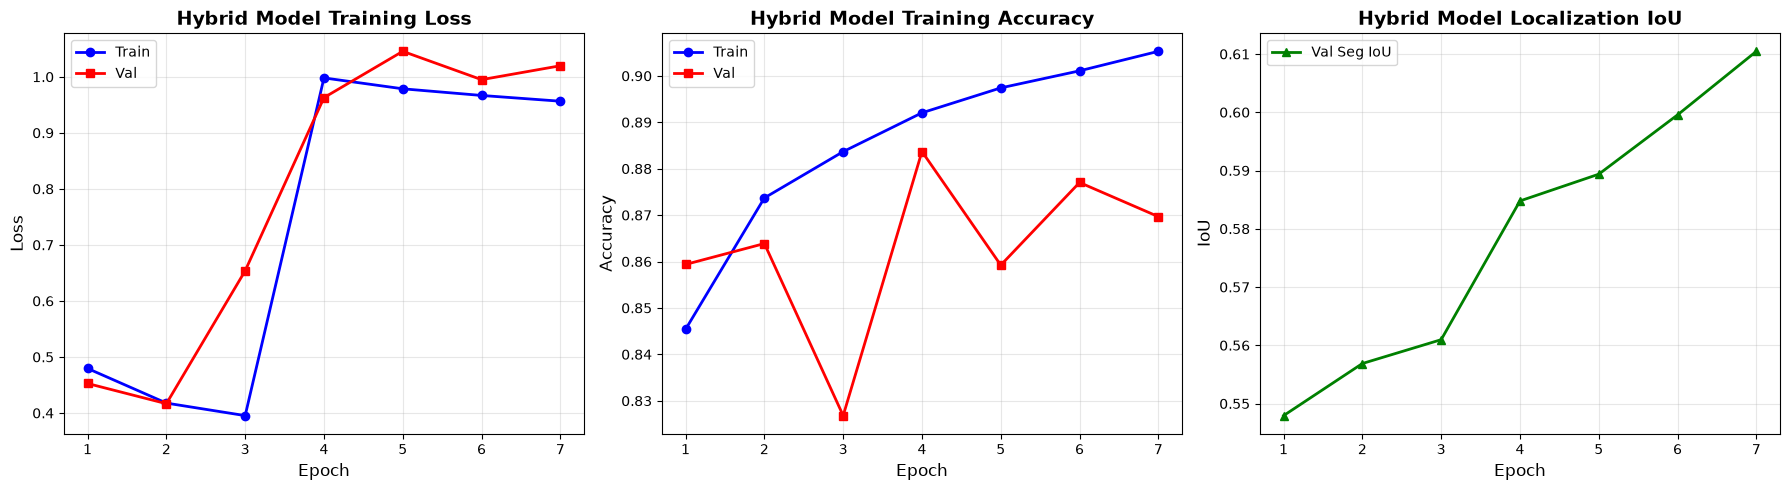


Loading best model checkpoint from: exp9\hybrid_best.pth
✓ Model successfully loaded (Best Epoch: 4, Val Acc: 0.8837)
Loaded test_data.pkl:
  Real: 33758, Fake: 33758, Total: 67516


Evaluating Test Set: 100%|██████████| 2110/2110 [36:11<00:00,  1.03s/it]



HYBRID CNN-ViT MODEL (EXP 9) TEST RESULTS
Classification Accuracy:  0.8680
Classification Precision: 0.8762
Classification Recall:    0.8570
Classification F1-Score:  0.8665
Classification ROC-AUC:   0.9518
Localization Mean IoU:    0.5705
Localization Mean Dice:   0.6232

✓ Saved test_metrics.csv and test_predictions.npz to exp9/
✓ ROC curve saved to exp9/roc_curve.png


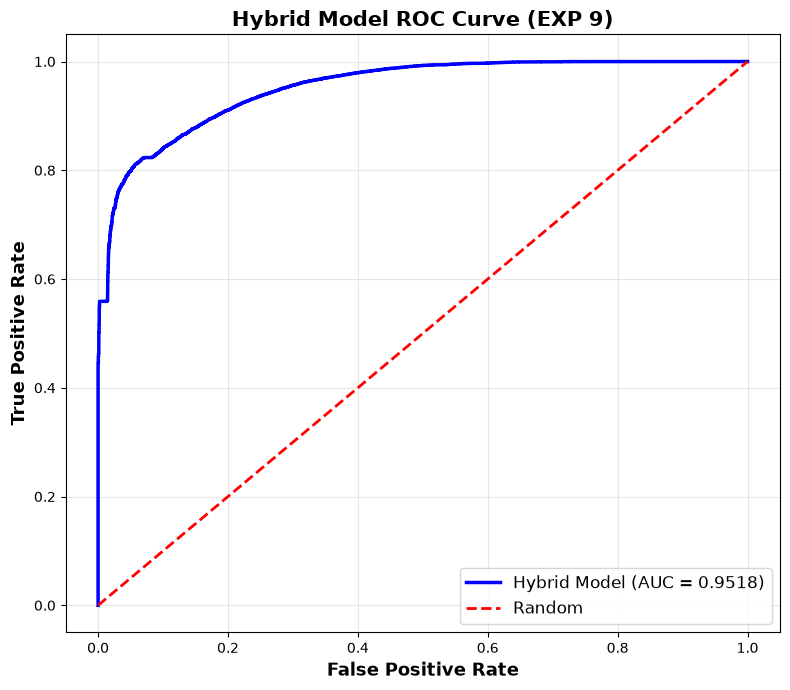


Generating sample visualization predictions...
✓ Sample visual predictions saved to exp9/sample_predictions.png


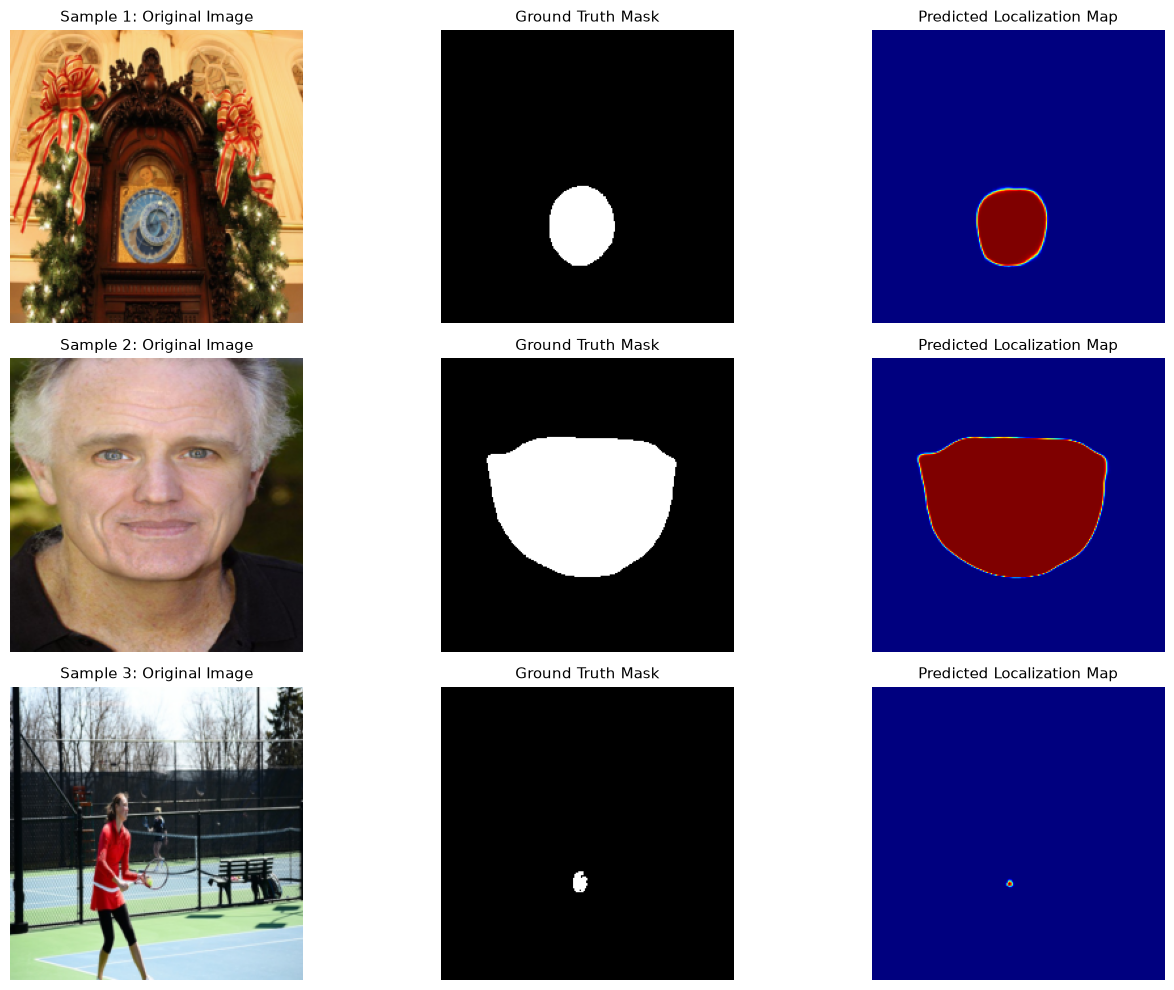


EXP 9 POST-TRAINING EVALUATION COMPLETED SUCCESSFULLY!


In [5]:
# ============================================================================
# STANDALONE EVALUATION & VISUALIZATION FOR EXP 9 (POST-TRAINING)
# ============================================================================

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve
)

# 1. Setup paths & device
best_model_path = os.path.join(Config.OUTPUT_DIR, "hybrid_best.pth")
history_path = os.path.join(Config.OUTPUT_DIR, "training_history.pkl")

print("="*70)
print("EXP 9: STANDALONE TEST EVALUATION & VISUALIZATION")
print("="*70)

# 2. Plot Training Curves from saved history
if os.path.exists(history_path):
    with open(history_path, 'rb') as f:
        history = pickle.load(f)
    
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Val', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Hybrid Model Training Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-s', label='Val', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Hybrid Model Training Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, history['val_seg_iou'], 'g-^', label='Val Seg IoU', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('IoU', fontsize=12)
    axes[2].set_title('Hybrid Model Localization IoU', fontsize=14, fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "training_curves.png"), dpi=300, bbox_inches='tight')
    print("✓ Training curves saved to exp9/training_curves.png")
    plt.show()

# 3. Load Best Trained Model
print(f"\nLoading best model checkpoint from: {best_model_path}")
model = HybridCNNViTClassifier(pretrained=False).to(Config.DEVICE)
checkpoint = torch.load(best_model_path, map_location=Config.DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✓ Model successfully loaded (Best Epoch: {checkpoint.get('epoch', 'N/A') + 1}, Val Acc: {checkpoint.get('val_acc', 0.0):.4f})")

# 4. Prepare Test DataLoader
test_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=Config.IMAGENET_MEAN, std=Config.IMAGENET_STD)
])
test_dataset = HybridManipulationDataset(Config.TEST_PKL, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

# 5. Evaluate on Test Set
all_labels, all_preds, all_probs = [], [], []
all_test_seg_ious = []
all_test_seg_dices = []

with torch.no_grad():
    for images, labels, masks in tqdm(test_loader, desc="Evaluating Test Set"):
        images = images.to(Config.DEVICE)
        masks = masks.to(Config.DEVICE)
        
        clf_out, seg_out, _ = model(images)
        probs = torch.sigmoid(clf_out)
        preds = probs > 0.5
        
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        
        # Compute Localization metrics on manipulated (fake) samples
        for i in range(images.size(0)):
            if labels[i].item() == 1.0:
                probs_seg = torch.sigmoid(seg_out[i])
                preds_seg = (probs_seg > 0.5).float()
                
                intersection = (preds_seg * masks[i]).sum()
                union = preds_seg.sum() + masks[i].sum() - intersection
                iou = (intersection + 1e-6) / (union + 1e-6)
                dice = (2. * intersection + 1e-6) / (preds_seg.sum() + masks[i].sum() + 1e-6)
                
                all_test_seg_ious.append(iou.item())
                all_test_seg_dices.append(dice.item())

# 6. Compute & Display Metrics
y_true = np.array(all_labels).flatten()
y_pred = np.array(all_preds).flatten()
y_prob = np.array(all_probs).flatten()

metrics = {
    'accuracy': accuracy_score(y_true, y_pred),
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall': recall_score(y_true, y_pred, zero_division=0),
    'f1_score': f1_score(y_true, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_true, y_prob),
    'mean_seg_iou': np.mean(all_test_seg_ious) if all_test_seg_ious else 0.0,
    'mean_seg_dice': np.mean(all_test_seg_dices) if all_test_seg_dices else 0.0
}

print(f"\n{'='*60}")
print("HYBRID CNN-ViT MODEL (EXP 9) TEST RESULTS")
print(f"{'='*60}")
print(f"Classification Accuracy:  {metrics['accuracy']:.4f}")
print(f"Classification Precision: {metrics['precision']:.4f}")
print(f"Classification Recall:    {metrics['recall']:.4f}")
print(f"Classification F1-Score:  {metrics['f1_score']:.4f}")
print(f"Classification ROC-AUC:   {metrics['roc_auc']:.4f}")
print(f"Localization Mean IoU:    {metrics['mean_seg_iou']:.4f}")
print(f"Localization Mean Dice:   {metrics['mean_seg_dice']:.4f}")
print(f"{'='*60}\n")

# Save metrics & predictions
pd.DataFrame([metrics]).to_csv(os.path.join(Config.OUTPUT_DIR, "test_metrics.csv"), index=False)
np.savez(
    os.path.join(Config.OUTPUT_DIR, "test_predictions.npz"),
    y_true=y_true, y_pred=y_pred, y_prob=y_prob
)
print("✓ Saved test_metrics.csv and test_predictions.npz to exp9/")

# 7. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'Hybrid Model (AUC = {metrics["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('Hybrid Model ROC Curve (EXP 9)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "roc_curve.png"), dpi=300, bbox_inches='tight')
print("✓ ROC curve saved to exp9/roc_curve.png")
plt.show()

# 8. Plot Sample Visualizations (Original vs Mask vs Prediction)
print("\nGenerating sample visualization predictions...")
vis_count = 0
plt.figure(figsize=(14, 10))

for images, labels, masks in test_loader:
    images_dev = images.to(Config.DEVICE)
    with torch.no_grad():
        _, seg_out, _ = model(images_dev)
    
    for i in range(images.size(0)):
        if labels[i].item() == 1.0 and vis_count < 3:
            img_np = images[i].permute(1, 2, 0).numpy()
            img_np = img_np * np.array(Config.IMAGENET_STD) + np.array(Config.IMAGENET_MEAN)
            img_np = np.clip(img_np, 0.0, 1.0)
            
            mask_np = masks[i].squeeze(0).numpy()
            pred_mask_np = torch.sigmoid(seg_out[i]).squeeze(0).cpu().numpy()
            
            plt.subplot(3, 3, vis_count * 3 + 1)
            plt.imshow(img_np)
            plt.title(f"Sample {vis_count+1}: Original Image", fontsize=11)
            plt.axis('off')
            
            plt.subplot(3, 3, vis_count * 3 + 2)
            plt.imshow(mask_np, cmap='gray')
            plt.title("Ground Truth Mask", fontsize=11)
            plt.axis('off')
            
            plt.subplot(3, 3, vis_count * 3 + 3)
            plt.imshow(pred_mask_np, cmap='jet')
            plt.title("Predicted Localization Map", fontsize=11)
            plt.axis('off')
            
            vis_count += 1
            
    if vis_count >= 3:
        break

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "sample_predictions.png"), dpi=300, bbox_inches='tight')
print("✓ Sample visual predictions saved to exp9/sample_predictions.png")
plt.show()

print("\n" + "="*70)
print("EXP 9 POST-TRAINING EVALUATION COMPLETED SUCCESSFULLY!")
print("="*70)


In [7]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()